## Guided Dataset

In [1]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Guided Gestures)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline and neural network approaches for predicting hand joint angles from sEMG signals using the guided gestures dataset.
# ---
# **Version:** GEGE (Updated Feature Selection)
# ---

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed
from contextlib import contextmanager
import warnings # To suppress specific warnings if needed

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # Key for preprocessing features
# from sklearn.impute import SimpleImputer # Example if needed, but unlikely for features
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, GridSearchCV, cross_val_predict
from sklearn.feature_selection import SequentialFeatureSelector, RFECV # Added RFECV
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression # Added Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config # For metadata routing

# PyTorch Modules (for Objective 5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress specific warnings (e.g., from Lasso convergence) if needed
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')


# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Configure metadata routing (needed for SFS and potentially CV with params)
try:
    set_config(enable_metadata_routing=True)
    print(f"Scikit-learn metadata routing enabled: {set_config(True)}") # Confirm it's set
except ValueError as e:
    print(f"Could not enable metadata routing (likely older scikit-learn): {e}")
    print("Proceeding without metadata routing. GroupKFold should still work directly.")


# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch device: {device}")

Scikit-learn metadata routing enabled: None
Using PyTorch device: cpu


In [2]:
# %% [markdown]
# ## 1. Load Data
#
# Load the guided gestures dataset files.

# %%
# File paths
X_TRAIN_VAL_PATH = "guided_dataset_X.npy"
Y_TRAIN_VAL_PATH = "guided_dataset_y.npy"
X_TEST_PATH = "guided_testset_X.npy"

# Load the training/validation data
try:
    X_train_val_raw = np.load(X_TRAIN_VAL_PATH)
    y_train_val_raw = np.load(Y_TRAIN_VAL_PATH)
    # Load the test data structure description (we need shape info for later)
    # Use allow_pickle=True if loading object arrays, though unlikely for this data
    X_test_raw_info = np.load(X_TEST_PATH, mmap_mode='r')
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    print("Please ensure the .npy files are in the correct directory.")
    # Handle error appropriately, maybe exit or raise
    raise e

# Print shapes to verify
print("Raw Training/Validation Data Shapes:")
print(f"X_train_val_raw: {X_train_val_raw.shape}")
print(f"y_train_val_raw: {y_train_val_raw.shape}")
print("\nRaw Test Data Shape (for info):")
print(f"X_test_raw_info: {X_test_raw_info.shape}")

# Constants derived from data
N_SESSIONS_TRAIN_VAL = X_train_val_raw.shape[0]
N_ELECTRODES = X_train_val_raw.shape[1]
N_TIME_POINTS_TRAIN_VAL = X_train_val_raw.shape[2]
N_JOINTS = y_train_val_raw.shape[1]

print(f"\nNumber of Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session: {N_TIME_POINTS_TRAIN_VAL}")
print(f"Number of Joints: {N_JOINTS}")


Data loaded successfully.
Raw Training/Validation Data Shapes:
X_train_val_raw: (5, 8, 230000)
y_train_val_raw: (5, 51, 230000)

Raw Test Data Shape (for info):
X_test_raw_info: (5, 332, 8, 500)

Number of Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session: 230000
Number of Joints: 51


In [3]:
# %% [markdown]
# ## 2. Signal Filtering (Optional but Applied)
#
# Applying DC offset removal, band-pass filtering (20-450 Hz), and **50Hz Notch filtering** to the raw sEMG data before windowing.

# %%
# Example (requires scipy):
from scipy.signal import butter, filtfilt, iirnotch # Added iirnotch

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs
     low = lowcut / nyq
     high = highcut / nyq
     if high >= 1.0: high = 0.99
     if low <= 0: raise ValueError("Lowcut frequency must be positive.")
     if low >= high: raise ValueError("Lowcut frequency must be less than Highcut.")
     b, a = butter(order, [low, high], btype='band')
     return b, a

# Function to create notch filter coefficients
def iir_notch(f0, Q, fs):
    """Designs notch filter coefficients."""
    b, a = iirnotch(f0, Q, fs)
    return b, a

def apply_filters(data, lowcut, highcut, notch_freq, notch_q, fs, bandpass_order=5):
     """Applies bandpass and notch filters sequentially."""
     # Apply bandpass filter first
     b_band, a_band = butter_bandpass(lowcut, highcut, fs, order=bandpass_order)
     if data.shape[-1] <= bandpass_order * 3: # Check length for bandpass
         print(f"Warning: Signal length ({data.shape[-1]}) too short for bandpass filter order ({bandpass_order}). Skipping bandpass.")
         filtered_data = data
     else:
         filtered_data = filtfilt(b_band, a_band, data, axis=-1)

     # Apply notch filter second
     b_notch, a_notch = iir_notch(notch_freq, notch_q, fs)
     # Check length for notch filter (filtfilt needs len > 3 * max(len(a), len(b)))
     # iirnotch usually results in order 2 (len 3), so check against ~9
     if filtered_data.shape[-1] <= 9:
          print(f"Warning: Signal length ({filtered_data.shape[-1]}) too short for notch filter. Skipping notch.")
          return filtered_data # Return bandpassed data
     else:
          y = filtfilt(b_notch, a_notch, filtered_data, axis=-1)
          return y

FS = 1024 # Sampling frequency from documentation
LOWCUT = 20
HIGHCUT = 450
NOTCH_FREQ = 50.0 # Powerline frequency
NOTCH_Q = 30.0    # Quality factor - controls bandwidth

with timer("Applying Signal Filtering (Bandpass + Notch)"):
    X_train_val_filtered = np.zeros_like(X_train_val_raw)
    for i in range(N_SESSIONS_TRAIN_VAL):
        # Remove DC offset (mean) per channel for the entire session
        session_data = X_train_val_raw[i]
        dc_removed = session_data - np.mean(session_data, axis=-1, keepdims=True)
        # Apply both filters
        X_train_val_filtered[i] = apply_filters(dc_removed, LOWCUT, HIGHCUT, NOTCH_FREQ, NOTCH_Q, FS)

    X_train_val_to_window = X_train_val_filtered
    print(f"Applied DC offset removal, bandpass ({LOWCUT}-{HIGHCUT}Hz), and notch ({NOTCH_FREQ}Hz) filtering.")



Applying Signal Filtering (Bandpass + Notch)...
Applied DC offset removal, bandpass (20-450Hz), and notch (50.0Hz) filtering.
Applying Signal Filtering (Bandpass + Notch) done in 2.49 seconds.



In [4]:
# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Objective 2)
#
# Segment the filtered sEMG and raw joint angle data into overlapping windows. Target `y` is the joint angle at the *end* of the window.

# %%
# Windowing Parameters
WINDOW_SIZE = 500  # k
OVERLAP_PERCENTAGE = 0.5 # Using 50% overlap

step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
if step <= 0:
    raise ValueError("Step size must be positive. Check window size and overlap.")
print(f"Window Size (k): {WINDOW_SIZE}")
print(f"Overlap: {OVERLAP_PERCENTAGE*100:.0f}%")
print(f"Step Size: {step}")

# (create_overlapping_windows function definition is the same as before)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []

    if n_timepoints < window_size:
        print(f"Warning: Session duration ({n_timepoints}) is less than window size ({window_size}). Cannot create windows.")
        return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)

    total_windows = 0
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]
        session_y = y_raw[session_idx]
        # Check if y data matches expected timepoints
        if session_y.shape[-1] != n_timepoints:
             print(f"Warning: Mismatch in timepoints between X ({n_timepoints}) and y ({session_y.shape[-1]}) for session {session_idx}. Skipping session.")
             continue

        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        num_session_windows = len(start_indices)

        if num_session_windows == 0:
            print(f"Warning: No windows created for session {session_idx} with current parameters.")
            continue

        for start_idx in start_indices:
            end_idx = start_idx + window_size
            # Ensure end_idx does not exceed bounds (shouldn't with arange logic, but good check)
            if end_idx > n_timepoints:
                continue
            window_X = session_X[:, start_idx:end_idx]
            # Target y is the value at the end of the window
            target_y = session_y[:, end_idx - 1]
            X_windowed_list.append(window_X)
            y_windowed_list.append(target_y)
            groups_list.append(session_idx)

        print(f"Session {session_idx}: Created {num_session_windows} windows.")
        total_windows += num_session_windows

    if total_windows == 0:
         print("Error: No windows were created for any session.")
         return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)

    # Stack the lists into numpy arrays
    # Use try-except for potential memory errors during stacking large lists
    try:
        X_windowed_np = np.stack(X_windowed_list)
        y_windowed_np = np.stack(y_windowed_list)
        groups_np = np.array(groups_list)
    except MemoryError as e:
        print(f"Memory Error during stacking: {e}. Dataset might be too large.")
        raise e
    except ValueError as e:
         print(f"Value Error during stacking (likely inconsistent shapes): {e}")
         # You might want to inspect the shapes in X_windowed_list here
         # for i, arr in enumerate(X_windowed_list): print(f"Window {i} shape: {arr.shape}")
         raise e

    return X_windowed_np, y_windowed_np, groups_np


# Create the windowed dataset
with timer("Creating overlapping windows"):
    X_windowed, y_windowed, groups = create_overlapping_windows(
        X_train_val_to_window, y_train_val_raw, WINDOW_SIZE, step
    )

if X_windowed.size == 0:
    print("Window creation failed. Exiting.")
else:
    print("\nWindowed Data Shapes:")
    print(f"X_windowed: {X_windowed.shape}")
    print(f"y_windowed: {y_windowed.shape}")
    print(f"Groups: {groups.shape}")
    print(f"Unique groups (sessions): {np.unique(groups)}")


Window Size (k): 500
Overlap: 50%
Step Size: 250
Creating overlapping windows...
Session 0: Created 919 windows.
Session 1: Created 919 windows.
Session 2: Created 919 windows.
Session 3: Created 919 windows.
Session 4: Created 919 windows.
Creating overlapping windows done in 0.37 seconds.


Windowed Data Shapes:
X_windowed: (4595, 8, 500)
y_windowed: (4595, 51)
Groups: (4595,)
Unique groups (sessions): [0 1 2 3 4]


In [5]:
# %% [markdown]
# ## 4. Data Preprocessing (Features)
#
# The primary preprocessing step after feature extraction is **normalization/scaling** using `StandardScaler`. This will be applied *within* cross-validation loops or pipelines to prevent data leakage.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.")

Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.


In [6]:
# %% [markdown]
# ## 5. Custom Feature Extractor (Baseline - Objective 4) - *Corrected for Cloning*
#
# Extracts time-domain features. `__init__` now only stores parameters. Feature resolution happens internally.

# %%
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """ Extracts time-domain features from EMG windows. Corrected for sklearn cloning. """
    # Define class constants for features
    ALL_AVAILABLE_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC'])
    REQUIRED_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR'])

    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False):
        # __init__ STRICTLY stores parameters as passed. NO modification here.
        self.zc_threshold = zc_threshold
        self.ssc_threshold = ssc_threshold
        self.selected_features = selected_features # Store whatever is passed (could be None, a list, etc.)
        self.verbose = verbose
        # No logic here that changes self.selected_features based on None or required_features

    def _get_features_to_extract(self):
        """Internal helper to determine the actual list of features to use."""
        if self.selected_features is None:
            # Default to all available features if none were specified
            return self.ALL_AVAILABLE_FEATURES
        else:
            # Ensure it's a list-like structure
            current_selection = list(self.selected_features)

            # Ensure selected features are valid
            invalid_features = [f for f in current_selection if f not in self.ALL_AVAILABLE_FEATURES]
            if invalid_features:
                # Raise error earlier if invalid features are provided
                raise ValueError(f"Invalid features specified: {invalid_features}. Allowed: {self.ALL_AVAILABLE_FEATURES}")

            # Ensure all required features are included
            features_to_use = set(current_selection)
            missing_required = [f for f in self.REQUIRED_FEATURES if f not in features_to_use]
            if missing_required:
                if self.verbose: print(f"Note: Adding missing required features: {missing_required}")
                features_to_use.update(missing_required)

            # Return a sorted list for consistent order
            return sorted(list(features_to_use))

    def fit(self, X, y=None):
        # Fit method doesn't need to do anything for these features
        # You could potentially validate features here if needed
        self._features_to_extract = self._get_features_to_extract()
        if self.verbose:
            print(f"Feature Extractor fit. Features to extract: {self._features_to_extract}")
        return self

    def transform(self, X):
        """ Transforms windowed EMG data into a feature matrix. """
        # Ensure fit has been called (or call it if not, less ideal for pure transform)
        if not hasattr(self, '_features_to_extract'):
             self.fit(X) # Call fit to determine features if transform is called directly

        features_to_extract = self._features_to_extract
        n_selected = len(features_to_extract)

        if n_selected == 0:
             print("Warning: No features selected for extraction. Returning empty array.")
             return np.empty((X.shape[0], 0))

        if X.ndim != 3:
            raise ValueError(f"Input X must be 3D (n_windows, n_electrodes, window_size), got {X.ndim}D")
        n_windows, n_electrodes, window_size = X.shape
        features = np.zeros((n_windows, n_electrodes * n_selected))

        if self.verbose: print(f"Extracting {n_selected} features from {n_windows} windows...")

        # Pre-calculate required stats per channel if needed by multiple features
        for i in range(n_windows):
            window_features = []
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                # Calculate stats needed by selected features ONCE
                stats = {}
                if any(f in features_to_extract for f in ['MAV', 'MPR']):
                    stats['abs_data'] = np.abs(channel_data)
                if any(f in features_to_extract for f in ['MAV']):
                    stats['mav'] = np.mean(stats['abs_data'])
                if any(f in features_to_extract for f in ['Var', 'STD', 'MPR']):
                    stats['var'] = np.var(channel_data)
                if any(f in features_to_extract for f in ['STD', 'MPR']):
                     # Ensure std is non-negative
                    stats['std'] = np.sqrt(stats['var']) if stats['var'] >= 0 else 0

                # Extract requested features in the determined order
                for feature_name in features_to_extract:
                    if feature_name == 'MAV':
                        window_features.append(stats['mav'])
                    elif feature_name == 'RMS':
                        window_features.append(np.sqrt(np.mean(channel_data**2)))
                    elif feature_name == 'Var':
                        window_features.append(stats['var'])
                    elif feature_name == 'STD':
                        window_features.append(stats['std'])
                    elif feature_name == 'ZC':
                        zc_count = np.sum(np.diff(np.signbit(channel_data - self.zc_threshold)))
                        window_features.append(zc_count)
                    elif feature_name == 'MPR':
                        threshold_mpr = stats['std'] if stats['std'] > 1e-9 else 1e-9
                        mpr = np.mean(stats['abs_data'] > threshold_mpr)
                        window_features.append(mpr)
                    elif feature_name == 'WL':
                        wl = np.sum(np.abs(np.diff(channel_data)))
                        window_features.append(wl)
                    elif feature_name == 'SSC':
                         diff_sig = np.diff(channel_data)
                         sign_change = (diff_sig[:-1] * diff_sig[1:]) < 0
                         magnitude_check = (np.abs(diff_sig[:-1]) > self.ssc_threshold) | (np.abs(diff_sig[1:]) > self.ssc_threshold)
                         ssc_count = np.sum(sign_change & magnitude_check)
                         window_features.append(ssc_count)
                    # Add other feature calculations if necessary

            # Assign features for the window
            if len(window_features) != n_electrodes * n_selected:
                 print(f"Warning: Mismatch in feature count for window {i}. Expected {n_electrodes * n_selected}, got {len(window_features)}. Filling with NaN.")
                 features[i, :] = np.nan
            else:
                 features[i, :] = window_features

        # Final check for NaNs/Infs introduced (e.g., if a window was skipped)
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        if self.verbose: print("Feature extraction complete.")
        return features

    def get_feature_names_out(self, input_features=None):
        """ Returns the names of the output features based on the resolved list. """
        # Ensure fit has been called to determine the actual features
        if not hasattr(self, '_features_to_extract'):
             # Determine features without modifying state if fit wasn't called
             # This might happen if only get_feature_names_out is called on an unfitted instance
             features_to_extract = self._get_features_to_extract()
        else:
             features_to_extract = self._features_to_extract

        feature_names = []
        try: # Get N_ELECTRODES safely
            global N_ELECTRODES
            num_electrodes = N_ELECTRODES
        except NameError:
            print("Warning: Global N_ELECTRODES not found for get_feature_names_out. Assuming 8.")
            num_electrodes = 8

        for j in range(num_electrodes):
            for feature_name in features_to_extract: # Use the resolved list
                feature_names.append(f"Elec{j+1}_{feature_name}")
        return np.array(feature_names)

# --- Re-run the testing cell ---
with timer("Testing CORRECTED Feature Extractor (All Features)"):
     # Ensure X_windowed exists and is not empty
     if 'X_windowed' not in locals() or X_windowed.size == 0:
          raise RuntimeError("X_windowed is not defined or empty. Cannot test Feature Extractor.")

     feature_extractor_all = EMGFeatureExtractor(verbose=False) # Create new instance
     # Fit must be called before transform or get_feature_names_out ideally
     feature_extractor_all.fit(X_windowed)
     X_features_all = feature_extractor_all.transform(X_windowed)

print("Feature Matrix Shape (All Features):")
print(f"X_features_all: {X_features_all.shape}")
# Use the internal list determined by fit for verification
n_expected_features_all = N_ELECTRODES * len(feature_extractor_all._features_to_extract)
print(f"Expected number of features per window: {n_expected_features_all}")
assert X_features_all.shape[1] == n_expected_features_all, "Feature dimension mismatch!"
feature_names_all = feature_extractor_all.get_feature_names_out()
print(f"\nGenerated {len(feature_names_all)} feature names. Examples: {feature_names_all[:5]}")

# Store the full feature set for later use
X_features = X_features_all
feature_names = feature_names_all

Testing CORRECTED Feature Extractor (All Features)...
Testing CORRECTED Feature Extractor (All Features) done in 18.54 seconds.

Feature Matrix Shape (All Features):
X_features_all: (4595, 64)
Expected number of features per window: 64

Generated 64 feature names. Examples: ['Elec1_MAV' 'Elec1_MPR' 'Elec1_RMS' 'Elec1_SSC' 'Elec1_STD']


Using GroupKFold with 5 splits (Leave-One-Session-Out).


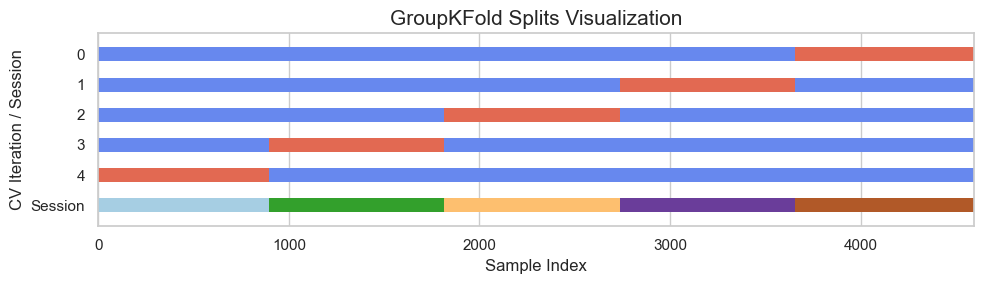

In [7]:
# %% [markdown]
# ## 6. Cross-Validation Strategy (Objective 3)
# (No changes needed here, use the cell from the original code)

# %%
N_SPLITS = N_SESSIONS_TRAIN_VAL # Use Leave-One-Session-Out
cv_strategy = GroupKFold(n_splits=N_SPLITS)
print(f"Using GroupKFold with {N_SPLITS} splits (Leave-One-Session-Out).")

# (plot_cv_indices function definition is the same as before)
def plot_cv_indices(cv, X, y, group, n_splits):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired; cmap_cv = plt.cm.coolwarm
    # Generate splits and plot
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan] * len(X)); indices[test_idx] = 1; indices[train_idx] = 0
        # Plotting the splits for each CV iteration
        ax.scatter(range(len(indices)), [i + .5] * len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    # Plotting the session groups
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    # Formatting the plot
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration / Session", ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15); plt.tight_layout(); plt.show()

# Plot for our setup using the generated features X_features
# Check if X_features is defined and not empty
if 'X_features' in locals() and X_features.size > 0:
    plot_cv_indices(cv_strategy, X_features, y_windowed, groups, N_SPLITS)
else:
    print("Skipping CV plot: X_features not available or empty.")


In [8]:
# %% [markdown]
# ## 7. Baseline Model Training and Evaluation (Objective 4 - Part 1: All Features)
#
# Evaluate Ridge, Lasso, and Random Forest regressors using *all* extracted time-domain features. The pipeline includes the **corrected** feature extractor and scaling.

# %%
# Define Performance Metrics (No changes needed here)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.maximum(mean_squared_error(y_true, y_pred), 0))

def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0, keepdims=True)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    if denominator < 1e-9: return 0.0 if numerator < 1e-9 else np.inf
    else: return numerator / denominator

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}
print("Scorers defined: RMSE (neg), NMSE (neg), R2.")

# %%
# Select Baseline Models (No changes needed here)
model_ridge = Ridge(alpha=1.0)
model_lasso = Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42)
model_rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, n_jobs=-1, random_state=42,
    max_features=0.33, min_samples_leaf=5
)

baseline_models_to_evaluate = {
    "Ridge": model_ridge,
    "Lasso": model_lasso,
    "RandomForest": model_rf
}

all_cv_results = {} # Reset results
results_summary_list = [] # Reset summary


# %%
# Evaluate baseline models using Cross-Validation with ALL features
print("--- Evaluating Baseline Models (Ridge, Lasso, RF) with ALL Features (Corrected Extractor) ---")

cv_params = {'groups': groups}

for model_name, model in baseline_models_to_evaluate.items():
    with timer(f"Cross-validating {model_name} (all features)"):
        # Pipeline: Use the CORRECTED EMGFeatureExtractor -> Scale -> Regress
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # Uses default (all) features implicitly
            ('scaling', StandardScaler()),
            ('regression', model)
        ])

        # Perform cross-validation (using the same try/except logic for compatibility)
        try:
             scores = cross_validate(
                 pipeline, X_windowed, y_windowed, cv=cv_strategy,
                 scoring=scorers, n_jobs=-1, return_train_score=False,
                 params=cv_params, error_score='raise'
             )
        except TypeError as e:
             if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed, passing groups directly to cv.split()...")
                fold_scores = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy.split(X_windowed, y_windowed, groups=groups)):
                    start_fit_time = time.time()
                    pipeline.fit(X_windowed[train_idx], y_windowed[train_idx])
                    end_fit_time = time.time()
                    y_pred = pipeline.predict(X_windowed[test_idx])
                    end_score_time = time.time()
                    fold_scores['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                         score_value = scorer_func(pipeline, X_windowed[test_idx], y_windowed[test_idx])
                         fold_scores[score_name].append(score_value)
                scores = {f"test_{key}": np.array(values) for key, values in fold_scores.items() if key in scorers}
                scores['fit_time'] = np.array(fold_scores['fit_time'])
                scores['score_time'] = np.array(fold_scores['score_time'])
             else: raise e

        all_cv_results[model_name] = scores # Store results

# %%
# Display Baseline CV Results (All Features) - Copied cell, should work now
print("\nBaseline Cross-Validation Performance Results (All Features):")

for model_name, scores in all_cv_results.items():
     if model_name in baseline_models_to_evaluate:
        mean_rmse = -np.nanmean(scores['test_rmse'])
        std_rmse = np.nanstd(scores['test_rmse'])
        mean_nmse = -np.nanmean(scores['test_nmse'])
        std_nmse = np.nanstd(scores['test_nmse'])
        mean_r2 = np.nanmean(scores['test_r2'])
        std_r2 = np.nanstd(scores['test_r2'])
        fit_time_mean = np.nanmean(scores['fit_time'])
        score_time_mean = np.nanmean(scores['score_time'])

        print(f"\n--- {model_name} (All Features) ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Fit Time: {fit_time_mean:.2f}s")
        print(f"  Avg Score Time: {score_time_mean:.2f}s")

        results_summary_list.append({
            'Model': model_name, 'Type': 'Baseline_AllFeat',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })

results_df = pd.DataFrame(results_summary_list)
print("\n--- Baseline Summary Table (All Features) ---")
# Ensure the DataFrame is not empty before filtering/printing
if not results_df.empty:
     print(results_df[results_df['Type'] == 'Baseline_AllFeat'].to_string(index=False, float_format="%.4f"))
else:
     print("Results DataFrame is empty.")


# %% [markdown]
# **Interpretation (All Features):**
# (No changes needed here)

Scorers defined: RMSE (neg), NMSE (neg), R2.
--- Evaluating Baseline Models (Ridge, Lasso, RF) with ALL Features (Corrected Extractor) ---
Cross-validating Ridge (all features)...
Cross-validating Ridge (all features) done in 56.06 seconds.

Cross-validating Lasso (all features)...
Cross-validating Lasso (all features) done in 69.20 seconds.

Cross-validating RandomForest (all features)...
Cross-validating RandomForest (all features) done in 150.16 seconds.


Baseline Cross-Validation Performance Results (All Features):

--- Ridge (All Features) ---
  RMSE: 7.3099 +/- 0.5291
  NMSE: 0.2665 +/- 0.0448
  R2 Score: 0.5817 +/- 0.0828
  Avg Fit Time: 27.52s
  Avg Score Time: 6.28s

--- Lasso (All Features) ---
  RMSE: 7.2993 +/- 0.5237
  NMSE: 0.2657 +/- 0.0441
  R2 Score: 0.5387 +/- 0.0862
  Avg Fit Time: 34.41s
  Avg Score Time: 3.73s

--- RandomForest (All Features) ---
  RMSE: 4.8070 +/- 0.8678
  NMSE: 0.1185 +/- 0.0472
  R2 Score: 0.6990 +/- 0.0730
  Avg Fit Time: 136.47s
  Avg Score T


--- Random Forest Feature Importance Analysis (Full Data - for Insight) ---
Extracting & Scaling features for Full Importance Analysis...
Extracting & Scaling features for Full Importance Analysis done in 22.58 seconds.

Training RandomForest on full scaled data for Importance Plot...
Training RandomForest on full scaled data for Importance Plot done in 25.55 seconds.


Random Forest Feature Importances (Top 30 - based on full data):


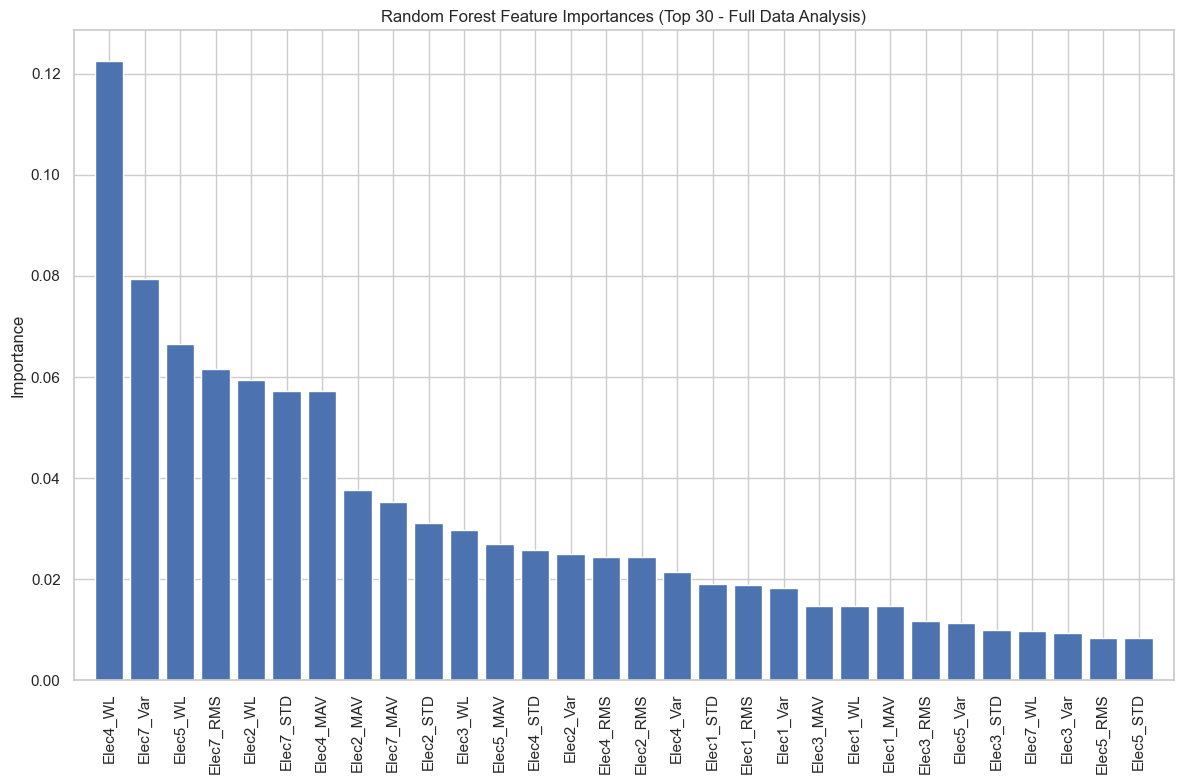


--- Evaluating Models with Integrated Feature Selection (Nested CV Approach - Expanded) ---

--- Processing Fold 1/5 for Integrated Feature Selection ---
  Fold 1: Feature Extraction...
  Fold 1: Feature Extraction done in 15.95 seconds.

  Fold 1: Scaling...
  Fold 1: Scaling done in 0.01 seconds.

  Fold 1: RFECV (estimator=Ridge, n_jobs=1)...
    RFECV selected 64 features.
  Fold 1: RFECV (estimator=Ridge, n_jobs=1) done in 0.69 seconds.

  Fold 1: Importance Selection (estimator=RF)...
    Importance selected top 32 features.
  Fold 1: Importance Selection (estimator=RF) done in 3.54 seconds.

  Fold 1: Evaluating Ridge with RFECV features (64)...
    Ridge_RFECV - RMSE: 7.0020, NMSE: 0.2332, R2: 0.6460
  Fold 1: Evaluating Ridge with RFECV features (64) done in 0.03 seconds.

  Fold 1: Evaluating RF with Importance features (32)...
    RF_Importance - RMSE: 4.4007, NMSE: 0.0921, R2: 0.7546
  Fold 1: Evaluating RF with Importance features (32) done in 6.24 seconds.

  Fold 1: Eva

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin, clone # <--- ADD clone HERE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # Key for preprocessing features

# %% [markdown]
# ## 8. Feature Importance Analysis and Integrated Selection (Objective 4 - Part 2: Selection)
#
# We now perform feature selection *correctly integrated within the cross-validation loop* to avoid data leakage. We will evaluate models using features selected by RFECV and Importance Thresholding within each fold.
#
# **Note:** Feature importance analysis (like the RF plot) can still be done on the full dataset for *understanding*, but the selection for *evaluation* must happen inside CV folds.

# %%
# --- Feature Importance Analysis (using RF trained on full data - for insight only) ---
print("\n--- Random Forest Feature Importance Analysis (Full Data - for Insight) ---")
# Need scaled features for analysis consistency
analysis_pipeline_full = Pipeline([
    ('feature_extraction', EMGFeatureExtractor()),
    ('scaling', StandardScaler())
])

with timer("Extracting & Scaling features for Full Importance Analysis"):
    X_features_scaled_full = analysis_pipeline_full.fit_transform(X_windowed, y_windowed)
    feature_names_full = analysis_pipeline_full.named_steps['feature_extraction'].get_feature_names_out()

# Train RF on the fully scaled data ONLY for this analysis plot
with timer("Training RandomForest on full scaled data for Importance Plot"):
    model_rf_analysis = RandomForestRegressor(
        n_estimators=200, max_depth=None, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5
    )
    model_rf_analysis.fit(X_features_scaled_full, y_windowed)

# Get and plot feature importances
importances_full = model_rf_analysis.feature_importances_
indices_full = np.argsort(importances_full)[::-1]
print("\nRandom Forest Feature Importances (Top 30 - based on full data):")
n_top_features_plot = 30
plt.figure(figsize=(12, 8))
plt.title("Random Forest Feature Importances (Top 30 - Full Data Analysis)")
top_indices = indices_full[:n_top_features_plot]
plt.bar(range(len(top_indices)), importances_full[top_indices], align='center')
plt.xticks(range(len(top_indices)), [feature_names_full[i] for i in top_indices], rotation=90)
plt.xlim([-1, len(top_indices)]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()
# --- End of Analysis Plot Section ---


# %% [markdown]
# ### 8.1 Cross-Validation with Integrated Feature Selection (Expanded)
#
# Evaluate combinations: Ridge+RFECV, RF+Importance, **Ridge+Importance**, **RF+RFECV**.
# **Note:** RFECV will run with n_jobs=1 to avoid pickling errors, making it slower.

# %%
print("\n--- Evaluating Models with Integrated Feature Selection (Nested CV Approach - Expanded) ---")

# RFECV Settings
MIN_FEATURES_RFECV = 10
STEP_RFECV = 5
CV_INNER_RFECV = 3 # Keep inner CV folds lower for speed

# Importance Thresholding Settings
N_FEATURES_IMPORTANCE = 32 # Number of top features from RF

# Store results for models with feature selection
fs_results = {
    # Original pairs
    "Ridge_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
    "RF_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
    # Added pairs
    "Ridge_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
    "RF_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
}

# Define models needed for evaluation (final step)
model_ridge_final = Ridge(alpha=1.0)
model_rf_final = RandomForestRegressor(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5
        )
# Define models needed for selection steps
model_ridge_for_rfecv = Ridge(alpha=1.0)
model_rf_for_importance = RandomForestRegressor( # Faster RF for importance calculation
                n_estimators=50, max_depth=10,
                n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5
            )


fold_num = 0
feature_extractor_cv = EMGFeatureExtractor() # Instantiate once outside loop

# Outer CV Loop (LOSO)
for train_idx, test_idx in cv_strategy.split(X_windowed, y_windowed, groups=groups):
    fold_num += 1
    print(f"\n--- Processing Fold {fold_num}/{N_SPLITS} for Integrated Feature Selection ---")
    start_fold_time = time.time()

    # 1. Split raw windowed data
    X_train_fold_raw, X_test_fold_raw = X_windowed[train_idx], X_windowed[test_idx]
    y_train_fold, y_test_fold = y_windowed[train_idx], y_windowed[test_idx]

    # 2. Extract features on fold data
    with timer(f"  Fold {fold_num}: Feature Extraction"):
        X_train_features = feature_extractor_cv.transform(X_train_fold_raw)
        X_test_features = feature_extractor_cv.transform(X_test_fold_raw)
        if fold_num == 1: feature_names = feature_extractor_cv.get_feature_names_out()

    # 3. Scale features (fit on train, transform train & test)
    with timer(f"  Fold {fold_num}: Scaling"):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_test_scaled = scaler.transform(X_test_features)

    # --- Feature Selection Step (on Fold's Training Data) ---
    selected_indices_rfecv = None
    n_features_rfecv = X_train_scaled.shape[1]
    selected_indices_importance = None
    n_features_importance = X_train_scaled.shape[1]

    # 4a. RFECV with Ridge (n_jobs=1)
    with timer(f"  Fold {fold_num}: RFECV (estimator=Ridge, n_jobs=1)"): # Slow step
        try:
            rfecv_selector = RFECV(
                estimator=clone(model_ridge_for_rfecv), # Clone estimator
                step=STEP_RFECV, cv=CV_INNER_RFECV, scoring=scorers['rmse'],
                min_features_to_select=MIN_FEATURES_RFECV,
                n_jobs=1 # Set n_jobs=1 to avoid pickling issues
            )
            rfecv_selector.fit(X_train_scaled, y_train_fold)
            selected_indices_rfecv = rfecv_selector.support_
            n_features_rfecv = rfecv_selector.n_features_
            print(f"    RFECV selected {n_features_rfecv} features.")
        except Exception as e:
            print(f"    RFECV failed for Fold {fold_num}: {e}. Using all features.")
            selected_indices_rfecv = np.ones(X_train_scaled.shape[1], dtype=bool)

    # 4b. Importance Thresholding with RandomForest
    with timer(f"  Fold {fold_num}: Importance Selection (estimator=RF)"):
        try:
            rf_importance_model = clone(model_rf_for_importance) # Clone estimator
            rf_importance_model.fit(X_train_scaled, y_train_fold)
            importances = rf_importance_model.feature_importances_
            indices_sorted = np.argsort(importances)[::-1]
            selected_indices_importance = np.zeros(X_train_scaled.shape[1], dtype=bool)
            n_select = min(N_FEATURES_IMPORTANCE, X_train_scaled.shape[1])
            selected_indices_importance[indices_sorted[:n_select]] = True
            n_features_importance = n_select
            print(f"    Importance selected top {n_features_importance} features.")
        except Exception as e:
            print(f"    Importance selection failed for Fold {fold_num}: {e}. Using all features.")
            selected_indices_importance = np.ones(X_train_scaled.shape[1], dtype=bool)


    # --- Model Evaluation Step (using selected features) ---
    # Helper function for evaluation to reduce repetition
    def evaluate_model(model_key, model_instance, X_train, y_train, X_test, y_test, selected_indices, n_features):
        if selected_indices is None or not np.any(selected_indices): # Check if selection failed or returned empty
             print(f"    Skipping {model_key} evaluation due to invalid feature indices.")
             # Append NaN or handle appropriately
             fs_results[model_key]['test_rmse'].append(np.nan)
             fs_results[model_key]['test_nmse'].append(np.nan)
             fs_results[model_key]['test_r2'].append(np.nan)
             fs_results[model_key]['n_features'].append(X_train.shape[1]) # Record original count if failed
             return

        X_train_sel = X_train[:, selected_indices]
        X_test_sel = X_test[:, selected_indices]
        model_instance = clone(model_instance) # Clone before fitting
        model_instance.fit(X_train_sel, y_train)
        y_pred = model_instance.predict(X_test_sel)
        rmse = root_mean_squared_error(y_test, y_pred)
        nmse = normalized_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        fs_results[model_key]['test_rmse'].append(-rmse)
        fs_results[model_key]['test_nmse'].append(-nmse)
        fs_results[model_key]['test_r2'].append(r2)
        fs_results[model_key]['n_features'].append(n_features)
        print(f"    {model_key} - RMSE: {rmse:.4f}, NMSE: {nmse:.4f}, R2: {r2:.4f}")

    fold_fit_start_time = time.time()

    # 5a. Evaluate Ridge_RFECV
    with timer(f"  Fold {fold_num}: Evaluating Ridge with RFECV features ({n_features_rfecv})"):
        evaluate_model("Ridge_RFECV", model_ridge_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)

    # 5b. Evaluate RF_Importance
    with timer(f"  Fold {fold_num}: Evaluating RF with Importance features ({n_features_importance})"):
        evaluate_model("RF_Importance", model_rf_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)

    # 5c. Evaluate Ridge_Importance
    with timer(f"  Fold {fold_num}: Evaluating Ridge with Importance features ({n_features_importance})"):
        evaluate_model("Ridge_Importance", model_ridge_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)

    # 5d. Evaluate RF_RFECV
    with timer(f"  Fold {fold_num}: Evaluating RF with RFECV features ({n_features_rfecv})"):
        evaluate_model("RF_RFECV", model_rf_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)

    # Record Timings
    fold_end_time = time.time()
    total_fold_time = fold_end_time - start_fold_time
    # Assign total time to all models evaluated in this fold (approximation)
    for key in ["Ridge_RFECV", "RF_Importance", "Ridge_Importance", "RF_RFECV"]:
        fs_results[key]['fit_time'].append(total_fold_time)
        fs_results[key]['score_time'].append(0) # Scoring integrated

# %%
# Aggregate and Display Results for Models with Integrated Feature Selection (Expanded)
# (Cell for displaying results is largely the same, just iterates through the updated fs_results)
print("\n--- Performance Results (Integrated Feature Selection - Expanded) ---")

# Need to check if results list exists and is populated
if 'results_summary_list' not in locals():
     results_summary_list = [] # Initialize if it doesn't exist

# Remove previous FS results before adding new ones, if script is re-run
results_summary_list = [item for item in results_summary_list if item['Type'] != 'Baseline_FS']


for model_fs_name, scores in fs_results.items():
    # Check if score lists are empty before calculating mean/std
    if not scores['test_rmse']:
        print(f"Warning: No scores recorded for {model_fs_name}. Skipping summary.")
        continue

    mean_rmse = -np.nanmean(scores['test_rmse'])
    std_rmse = np.nanstd(scores['test_rmse'])
    mean_nmse = -np.nanmean(scores['test_nmse'])
    std_nmse = np.nanstd(scores['test_nmse'])
    mean_r2 = np.nanmean(scores['test_r2'])
    std_r2 = np.nanstd(scores['test_r2'])
    fit_time_mean = np.nanmean(scores['fit_time'])
    avg_n_features = np.nanmean(scores['n_features'])
    std_n_features = np.nanstd(scores['n_features'])

    print(f"\n--- {model_fs_name} ---")
    print(f"  Avg. Features Selected: {avg_n_features:.1f} +/- {std_n_features:.1f}")
    print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
    print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
    print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
    print(f"  Avg Total Time per Fold: {fit_time_mean:.2f}s")

    # Add to summary list for final table
    results_summary_list.append({
        'Model': model_fs_name, 'Type': 'Baseline_FS',
        'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
        'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
        'R2_mean': mean_r2, 'R2_std': std_r2,
        'FitTime': fit_time_mean
    })

# Update and display the comparison table including expanded FS results
results_df = pd.DataFrame(results_summary_list)
print("\n--- Updated Summary Table (Including Expanded Integrated FS) ---")
if not results_df.empty:
    print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else:
    print("Results DataFrame is empty.")

# Clean up large intermediate variables if memory is a concern
# del X_train_features, X_test_features, X_train_scaled, X_test_scaled
# gc.collect() # Already done later

In [10]:
import gc  # For garbage collection 

# %% [markdown]
# ## 9. Sophisticated Approach: Neural Network (Objective 5) - *No changes needed here*
#
# Implement and evaluate the MLP using PyTorch, performing cross-validation manually with scaling inside the loop.

# %%
# Define the Neural Network Architecture (Copied from original GEGE)
class EMG_NN(nn.Module):
    def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
        super(EMG_NN, self).__init__()
        self.layer_1 = nn.Linear(n_features, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.batchnorm1 = nn.BatchNorm1d(hidden_dim1) # Added BatchNorm
        self.dropout1 = nn.Dropout(dropout_p)
        self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.batchnorm2 = nn.BatchNorm1d(hidden_dim2) # Added BatchNorm
        self.dropout2 = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_dim2, n_joints)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.batchnorm1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.batchnorm2(self.layer_2(x))))
        x = self.output_layer(x)
        return x

# %%
# Training and Evaluation Functions for PyTorch NN (Copied from original GEGE)

def train_nn_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad() # Zero gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, targets) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        running_loss += loss.item() * inputs.size(0) # Accumulate loss

    return running_loss / len(dataloader.dataset) # Return average loss for the epoch

def evaluate_nn_model(model, dataloader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad(): # Disable gradient calculations
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, targets) # Calculate loss
            running_loss += loss.item() * inputs.size(0) # Accumulate loss
            all_preds.append(outputs.cpu().numpy()) # Collect predictions (move back to CPU)
            all_targets.append(targets.cpu().numpy()) # Collect targets

    avg_loss = running_loss / len(dataloader.dataset)
    # Concatenate predictions and targets from all batches
    predictions = np.concatenate(all_preds)
    true_values = np.concatenate(all_targets)
    return avg_loss, predictions, true_values

# %%
# Manual Cross-Validation Loop for Neural Network (Copied from original GEGE)

# Hyperparameters
N_EPOCHS = 75 # Adjust as needed based on convergence
BATCH_SIZE = 64
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5 # L2 regularization for Adam

# NN requires features as input, use the full feature set generated earlier
# Ensure X_features (all features) and feature_names are available
if 'X_features' not in locals() or 'feature_names' not in locals():
     raise RuntimeError("X_features or feature_names not available for NN CV. Rerun feature extraction.")
X_input_for_nn_cv = X_features # Use the matrix with all features
n_input_features = X_input_for_nn_cv.shape[1]

nn_cv_scores = {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': []}
print(f"\n--- Evaluating Neural Network (Manual CV, Input Features: {n_input_features}) ---")

fold_num = 0
for train_idx, val_idx in cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups):
    fold_num += 1
    print(f"\nStarting NN CV Fold {fold_num}/{N_SPLITS}")
    start_fold_time = time.time()

    # 1. Split feature data for this fold
    X_train_fold, X_val_fold = X_input_for_nn_cv[train_idx], X_input_for_nn_cv[val_idx]
    y_train_fold, y_val_fold = y_windowed[train_idx], y_windowed[val_idx]

    # 2. Scale features based *only* on training data for this fold
    scaler_nn_fold = StandardScaler()
    X_train_fold_scaled = scaler_nn_fold.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler_nn_fold.transform(X_val_fold) # Use same scaler for validation

    # 3. Create PyTorch Datasets and DataLoaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold))
    val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

    # 4. Initialize model, loss, optimizer for this fold
    model_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
    criterion = nn.MSELoss() # Use MSE for regression
    optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # Optional: Add a learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=True)


    # 5. Training loop with validation loss monitoring
    best_val_loss = float('inf')
    epochs_no_improve = 0
    patience = 15 # For early stopping based on validation loss

    print(f"Fold {fold_num}: Training for up to {N_EPOCHS} epochs...")
    for epoch in range(N_EPOCHS):
        train_loss = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        val_loss_epoch, _, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)

        if (epoch + 1) % 10 == 0 or epoch == N_EPOCHS - 1:
             print(f'  Epoch {epoch+1}/{N_EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss_epoch:.6f}')

        # Update LR scheduler
        scheduler.step(val_loss_epoch)

        # Early Stopping Check
        if val_loss_epoch < best_val_loss:
             best_val_loss = val_loss_epoch
             epochs_no_improve = 0
             # Optional: Save the best model state for this fold
             # torch.save(model_nn.state_dict(), f'best_model_fold_{fold_num}.pth')
        else:
             epochs_no_improve += 1

        if epochs_no_improve >= patience:
             print(f"  Early stopping triggered at epoch {epoch + 1}")
             break

    fit_end_time = time.time()
    # Optional: Load the best model state if saved

    # 6. Evaluate on validation set
    print(f"Fold {fold_num}: Evaluating on validation set...")
    val_loss, y_pred_fold, y_true_fold = evaluate_nn_model(model_nn, val_loader, criterion, device)
    score_end_time = time.time()

    # 7. Calculate and store metrics for this fold
    rmse_fold = root_mean_squared_error(y_true_fold, y_pred_fold)
    nmse_fold = normalized_mean_squared_error(y_true_fold, y_pred_fold)
    r2_fold = r2_score(y_true_fold, y_pred_fold)

    nn_cv_scores['test_rmse'].append(-rmse_fold) # Store negative for consistency with scorers
    nn_cv_scores['test_nmse'].append(-nmse_fold)
    nn_cv_scores['test_r2'].append(r2_fold)
    nn_cv_scores['fit_time'].append(fit_end_time - start_fold_time)
    nn_cv_scores['score_time'].append(score_end_time - fit_end_time)

    print(f"Fold {fold_num} Metrics: RMSE={rmse_fold:.4f}, NMSE={nmse_fold:.4f}, R2={r2_fold:.4f}")
    # Clean up GPU memory if needed
    del model_nn, train_loader, val_loader, train_dataset, val_dataset
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()


# Store overall NN results
all_cv_results["NeuralNetwork"] = nn_cv_scores

# %%
# Add NN results to the summary DataFrame
nn_model_name = "NeuralNetwork"
if nn_model_name in all_cv_results: # Check if NN ran successfully
    nn_scores = all_cv_results[nn_model_name]
    mean_rmse = -np.nanmean(nn_scores['test_rmse'])
    std_rmse = np.nanstd(nn_scores['test_rmse'])
    mean_nmse = -np.nanmean(nn_scores['test_nmse'])
    std_nmse = np.nanstd(nn_scores['test_nmse'])
    mean_r2 = np.nanmean(nn_scores['test_r2'])
    std_r2 = np.nanstd(nn_scores['test_r2'])
    fit_time_mean = np.nanmean(nn_scores['fit_time'])
    # score_time_mean = np.nanmean(nn_scores['score_time']) # Score time seems less relevant here

    results_summary_list.append({
        'Model': nn_model_name, 'Type': 'Sophisticated',
        'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
        'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
        'R2_mean': mean_r2, 'R2_std': std_r2,
        'FitTime': fit_time_mean
    })

    # Update and display the final comparison table
    results_df = pd.DataFrame(results_summary_list)
    print("\n--- Combined Model Comparison Table (incl. NN) ---")
    print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else:
    print("Neural Network results not found in all_cv_results.")



--- Evaluating Neural Network (Manual CV, Input Features: 64) ---

Starting NN CV Fold 1/5


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 1: Training for up to 75 epochs...
  Epoch 10/75, Train Loss: 107.028198, Val Loss: 102.387305
  Epoch 20/75, Train Loss: 48.544493, Val Loss: 38.272976
  Epoch 30/75, Train Loss: 32.424870, Val Loss: 23.388776
  Epoch 40/75, Train Loss: 31.265096, Val Loss: 18.898005
  Epoch 50/75, Train Loss: 28.892594, Val Loss: 17.936491
  Epoch 60/75, Train Loss: 26.706551, Val Loss: 17.660795
  Epoch 70/75, Train Loss: 27.878073, Val Loss: 15.899303
  Epoch 75/75, Train Loss: 26.451405, Val Loss: 16.814081
Fold 1: Evaluating on validation set...
Fold 1 Metrics: RMSE=4.1005, NMSE=0.0800, R2=-28107868.0000

Starting NN CV Fold 2/5
Fold 2: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/75, Train Loss: 105.480567, Val Loss: 94.220814
  Epoch 20/75, Train Loss: 47.532617, Val Loss: 32.689590
  Epoch 30/75, Train Loss: 32.064718, Val Loss: 17.403318
  Epoch 40/75, Train Loss: 30.452030, Val Loss: 15.012576
  Epoch 50/75, Train Loss: 29.483633, Val Loss: 15.360779
  Epoch 60/75, Train Loss: 28.918935, Val Loss: 13.963514
  Epoch 70/75, Train Loss: 27.759669, Val Loss: 15.438738
  Epoch 75/75, Train Loss: 26.390330, Val Loss: 13.765731
Fold 2: Evaluating on validation set...
Fold 2 Metrics: RMSE=3.7102, NMSE=0.0697, R2=-30727218.0000

Starting NN CV Fold 3/5
Fold 3: Training for up to 75 epochs...


...

  Epoch 10/75, Train Loss: 104.811255, Val Loss: 104.338307
  Epoch 20/75, Train Loss: 47.422614, Val Loss: 42.767087
  Epoch 30/75, Train Loss: 34.250427, Val Loss: 26.421761
  Epoch 40/75, Train Loss: 29.694737, Val Loss: 25.156463
  Epoch 50/75, Train Loss: 28.516424, Val Loss: 25.949451
  Epoch 60/75, Train Loss: 27.780635, Val Loss: 24.914920
  Early stopping triggered at epoch 68
Fold 3: Evaluating on validation set...
Fold 3 Metrics: RMSE=4.7306, NMSE=0.1051, R2=-30957024.0000

Starting NN CV Fold 4/5


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 4: Training for up to 75 epochs...
  Epoch 10/75, Train Loss: 109.583112, Val Loss: 108.888219
  Epoch 20/75, Train Loss: 51.733589, Val Loss: 44.470049
  Epoch 30/75, Train Loss: 34.945877, Val Loss: 28.271037
  Epoch 40/75, Train Loss: 29.071570, Val Loss: 22.205603
  Epoch 50/75, Train Loss: 28.270006, Val Loss: 22.198071
  Epoch 60/75, Train Loss: 28.523748, Val Loss: 24.018919
  Early stopping triggered at epoch 61
Fold 4: Evaluating on validation set...
Fold 4 Metrics: RMSE=4.5918, NMSE=0.1071, R2=-16855466.0000

Starting NN CV Fold 5/5
Fold 5: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/75, Train Loss: 102.016963, Val Loss: 105.976290
  Epoch 20/75, Train Loss: 47.028465, Val Loss: 54.782169
  Epoch 30/75, Train Loss: 34.087606, Val Loss: 35.793306
  Epoch 40/75, Train Loss: 28.377100, Val Loss: 28.832933
  Epoch 50/75, Train Loss: 28.856496, Val Loss: 28.377959
  Epoch 60/75, Train Loss: 27.375264, Val Loss: 24.184177
  Early stopping triggered at epoch 66
Fold 5: Evaluating on validation set...
Fold 5 Metrics: RMSE=5.0964, NMSE=0.1340, R2=-39251160.0000

--- Combined Model Comparison Table (incl. NN) ---
           Model             Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std        R2_mean       R2_std  FitTime
   NeuralNetwork    Sophisticated     4.4459    0.4870     0.0992    0.0226 -29179747.2000 7211429.3535 779.1967
        RF_RFECV      Baseline_FS     4.7953    0.8263     0.1176    0.0447         0.6999       0.0724  36.0539
    RandomForest Baseline_AllFeat     4.8070    0.8678     0.1185    0.0472         0.6990       0.0730 136.4672
   RF_I

In [11]:
# %% [markdown]
# ## 10. Objective 6: Ensembling Strategies
#
# Implement Averaging and Stacking ensembles using the out-of-fold predictions from the baseline models (using all features) and the Neural Network.

# %% [markdown]
# ### 10.1 Generate Out-of-Fold (OOF) Predictions
#
# Get OOF predictions for models intended for ensembling (typically the best performing variations). We'll use the baseline models trained on ALL features and the Neural Network.

# %%
oof_predictions = {} # Dictionary to store OOF predictions

# --- OOF Predictions for Baseline Models (All Features) ---
print("--- Generating OOF Predictions for Baseline Models (All Features) ---")
baseline_pipelines_oof = {}
# Use the models defined in baseline_models_to_evaluate
for model_name, model in baseline_models_to_evaluate.items():
     baseline_pipelines_oof[model_name] = Pipeline([
          ('feature_extraction', EMGFeatureExtractor()), # All features
          ('scaling', StandardScaler()),
          ('regression', model)
     ])

# Use cross_val_predict
for model_name, pipeline in baseline_pipelines_oof.items():
     with timer(f"Generating OOF predictions for {model_name}"):
          try:
               # Try with metadata routing first
               oof_preds = cross_val_predict(
                   pipeline, X_windowed, y_windowed, cv=cv_strategy,
                   n_jobs=-1, method='predict', params={'groups': groups}
               )
          except TypeError as e:
               # Fallback if metadata routing fails
               if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                    print("Metadata routing failed for cross_val_predict, using manual loop...")
                    oof_preds_list = [None] * len(X_windowed)
                    for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy.split(X_windowed, y_windowed, groups=groups)):
                        pipeline.fit(X_windowed[train_idx], y_windowed[train_idx])
                        fold_preds = pipeline.predict(X_windowed[test_idx])
                        for i, idx in enumerate(test_idx):
                            oof_preds_list[idx] = fold_preds[i]
                    oof_preds = np.stack(oof_preds_list)
               else:
                   raise e
          oof_predictions[model_name] = oof_preds
     print(f"Shape of {model_name} OOF predictions: {oof_preds.shape}")

# --- OOF Predictions for Neural Network ---
print("\n--- Generating OOF Predictions for Neural Network (Manual CV - Reuse previous logic) ---")
# We need to run the manual CV loop again, focusing on collecting predictions

# Ensure NN hyperparameters are defined (consistency)
N_EPOCHS_OOF = 75 # Same number of epochs used in evaluation
BATCH_SIZE_OOF = 64
LEARNING_RATE_OOF = 0.001
WEIGHT_DECAY_OOF = 1e-5

nn_oof_preds_list = [None] * len(X_input_for_nn_cv) # List to store predictions
nn_indices_list = [] # To verify order

if 'X_input_for_nn_cv' not in locals() or X_input_for_nn_cv is None:
     raise ValueError("NN features (X_input_for_nn_cv) not found. Cannot generate OOF.")
n_input_features_oof = X_input_for_nn_cv.shape[1]

fold_num = 0
with timer("Generating OOF predictions for Neural Network (Manual CV)"):
    for train_idx, val_idx in cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups):
        fold_num += 1
        if fold_num % 2 == 0: print(f"  Processing NN OOF Fold {fold_num}/{N_SPLITS}") # Print progress less often

        # 1. Split data
        X_train_fold, X_val_fold = X_input_for_nn_cv[train_idx], X_input_for_nn_cv[val_idx]
        y_train_fold, y_val_fold = y_windowed[train_idx], y_windowed[val_idx]

        # 2. Scale features
        scaler_oof = StandardScaler()
        X_train_fold_scaled = scaler_oof.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler_oof.transform(X_val_fold)

        # 3. Datasets & DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold))
        val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_OOF, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_OOF*2, shuffle=False) # Larger batch for eval

        # 4. Initialize model, loss, optimizer
        model_nn_oof = EMG_NN(n_features=n_input_features_oof, n_joints=N_JOINTS).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model_nn_oof.parameters(), lr=LEARNING_RATE_OOF, weight_decay=WEIGHT_DECAY_OOF)

        # 5. Training loop (no early stopping needed here, train for fixed epochs)
        for epoch in range(N_EPOCHS_OOF):
            _ = train_nn_epoch(model_nn_oof, train_loader, criterion, optimizer, device)

        # 6. Evaluate and GET PREDICTIONS on validation set
        _, y_pred_fold, _ = evaluate_nn_model(model_nn_oof, val_loader, criterion, device)

        # 7. Store predictions
        for i, idx in enumerate(val_idx):
            if idx < len(nn_oof_preds_list): # Boundary check
                 nn_oof_preds_list[idx] = y_pred_fold[i]
            else:
                 print(f"Warning: Index {idx} out of bounds for nn_oof_preds_list (size {len(nn_oof_preds_list)})")
        nn_indices_list.extend(val_idx.tolist())

        # Clean up
        del model_nn_oof, train_loader, val_loader, train_dataset, val_dataset
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()


# Combine the list of predictions into a single numpy array
# Check if all predictions were filled
contains_none = any(pred is None for pred in nn_oof_preds_list)

if contains_none:
    print("Warning: Some NN OOF predictions are missing (None found). Filling with zeros.")
    # Find average prediction shape from non-None entries
    # Filter out None before checking shapes
    shapes = [p.shape for p in nn_oof_preds_list if p is not None]
    if not shapes:
        raise ValueError("Cannot determine NN prediction shape, all OOF preds are None.")
    avg_shape = shapes[0] # Assume consistent shape
    fill_value = np.zeros(avg_shape)
    # Fill None values correctly
    nn_oof_preds_filled = [p if p is not None else fill_value for p in nn_oof_preds_list]
    oof_predictions["NeuralNetwork"] = np.stack(nn_oof_preds_filled)
else:
     # If no None is found, stack directly
     oof_predictions["NeuralNetwork"] = np.stack(nn_oof_preds_list)


# Verification
print(f"Shape of NN OOF predictions: {oof_predictions['NeuralNetwork'].shape}")
# Ensure all models intended for ensembling have OOF predictions
ensemble_model_names = list(baseline_models_to_evaluate.keys()) + ["NeuralNetwork"]
missing_oof = [name for name in ensemble_model_names if name not in oof_predictions]
if missing_oof:
     raise RuntimeError(f"Missing OOF predictions for models: {missing_oof}")


# %% [markdown]
# ### 10.2 Averaging Ensemble
#
# Compute the simple average of the OOF predictions.

# %%
print("\n--- Evaluating Averaging Ensemble ---")
model_names_for_avg = list(oof_predictions.keys()) # Use all available OOF preds
print(f"Averaging predictions from models: {model_names_for_avg}")

# Summing up the predictions
oof_preds_sum = np.zeros_like(y_windowed, dtype=np.float64) # Use y_windowed shape/dtype
for model_name in model_names_for_avg:
    oof_preds_sum += oof_predictions[model_name]

# Calculating the average
oof_preds_avg = oof_preds_sum / len(model_names_for_avg)

# Evaluate the performance of the averaged predictions ONCE using the full OOF set
avg_rmse = root_mean_squared_error(y_windowed, oof_preds_avg)
avg_nmse = normalized_mean_squared_error(y_windowed, oof_preds_avg)
avg_r2 = r2_score(y_windowed, oof_preds_avg)

print(f"\nAveraging Ensemble Performance (on OOF predictions):")
print(f"  RMSE: {avg_rmse:.4f}")
print(f"  NMSE: {avg_nmse:.4f}")
print(f"  R2 Score: {avg_r2:.4f}")

# Add results to summary
results_summary_list.append({
    'Model': 'AverageEnsemble', 'Type': 'Ensemble',
    'RMSE_mean': avg_rmse, 'RMSE_std': np.nan, # No std dev from single OOF evaluation
    'NMSE_mean': avg_nmse, 'NMSE_std': np.nan,
    'R2_mean': avg_r2, 'R2_std': np.nan,
    'FitTime': np.nan # Fit time is combination of base models
})
# Update results_df
results_df = pd.DataFrame(results_summary_list)


# %% [markdown]
# ### 10.3 Stacking Ensemble (Meta-Learner - Expanded Evaluation)
#
# Train and evaluate different meta-learners (Ridge, Lasso, RandomForest)
# on the OOF predictions using cross-validation.
# %%
print("\n--- Evaluating Stacking Ensemble (Multiple Meta-Learners) ---")

# 1. Create Meta-Features (if not already created or cleared)
recreate_x_meta = True # Flag to determine if X_meta needs to be created/recreated

# Check if X_meta exists, is valid, and matches current y_windowed
if 'X_meta' in locals() and X_meta is not None:
    if isinstance(X_meta, np.ndarray) and X_meta.shape[0] == len(y_windowed):
        print("Using existing meta-features (X_meta).")
        # Ensure model_names_for_stacking is available if reusing X_meta
        if 'model_names_for_stacking' not in locals() or not model_names_for_stacking:
             model_names_for_stacking = list(oof_predictions.keys())
        recreate_x_meta = False
    elif not isinstance(X_meta, np.ndarray):
        print(f"X_meta exists but is not a NumPy array (type: {type(X_meta)}). Recreating meta-features...")
    else: # Exists, is an ndarray, but shape is wrong
        print(f"X_meta shape ({X_meta.shape[0]}) mismatch with y_windowed ({len(y_windowed)}). Recreating meta-features...")
elif 'X_meta' in locals() and X_meta is None:
    print("X_meta is None. Recreating meta-features...")
else: # 'X_meta' not in locals()
    print("X_meta not found. Creating guided meta-features...")

if recreate_x_meta:
    if 'oof_predictions' not in locals() or not oof_predictions:
        raise RuntimeError("oof_predictions dictionary is missing or empty. Cannot create X_meta. Please run OOF generation first.")

    model_names_for_stacking = list(oof_predictions.keys())
    X_meta_list = []
    
    print("Preparing to create X_meta from OOF predictions:")
    for model_name in model_names_for_stacking:
        pred = oof_predictions.get(model_name)
        if pred is None:
            raise ValueError(f"OOF prediction for model '{model_name}' is None. Cannot create X_meta. Check OOF generation for this model.")
        if not isinstance(pred, np.ndarray):
            raise TypeError(f"OOF prediction for model '{model_name}' is not a NumPy array (type: {type(pred)}). Cannot create X_meta.")
        if pred.shape[0] != len(y_windowed):
            raise ValueError(f"OOF prediction for model '{model_name}' has incorrect number of samples ({pred.shape[0]}) compared to y_windowed ({len(y_windowed)}).")
        print(f"  OOF for {model_name}: shape={pred.shape}, type={type(pred)}")
        X_meta_list.append(pred)

    if not X_meta_list:
        raise ValueError("X_meta_list is empty (no valid OOF predictions found to stack).")

    try:
        X_meta = np.hstack(X_meta_list)
        print(f"Successfully created Meta-Features (X_meta). Shape: {X_meta.shape}")
    except (ValueError, TypeError) as e: # Catch common hstack errors
        print(f"Error stacking OOF predictions: {e}")
        print("Details of arrays in X_meta_list that were attempted to stack:")
        for i, arr_in_list in enumerate(X_meta_list):
            m_name = model_names_for_stacking[i] if i < len(model_names_for_stacking) else "Unknown"
            print(f"  Model {m_name}: type={type(arr_in_list)}, shape={getattr(arr_in_list, 'shape', 'N/A')}")
        X_meta = None # Ensure X_meta is None if stacking fails
        raise # Re-raise the error to stop execution and highlight the problem

# Final check after creation/reuse attempt
if X_meta is None:
    raise RuntimeError("X_meta is None after creation/reuse attempt. Cannot proceed with Stacking Ensemble.")
if not isinstance(X_meta, np.ndarray) or X_meta.shape[0] != len(y_windowed):
     raise RuntimeError(f"X_meta is invalid or shape mismatch after creation/reuse. Shape: {getattr(X_meta, 'shape', 'N/A')}, Expected samples: {len(y_windowed)}")


# 2. Define Meta-Learners to test
meta_learners = {
    "Stacking_Ridge": Ridge(alpha=1.0),
    "Stacking_Lasso": Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42),
    "Stacking_RF": RandomForestRegressor(
        n_estimators=50,
        max_depth=5,
        n_jobs=-1,
        random_state=42,
        max_features=0.5
    )
}

# 3. Cross-Validate each Meta-Learner
for meta_name, meta_model in meta_learners.items():
    print(f"\n--- Cross-validating Meta-Learner: {meta_name} ---")
    with timer(f"Cross-validating {meta_name}"):
        stacking_pipeline = Pipeline([
            ('meta_regression', meta_model)
        ])
        try:
            stacking_scores = cross_validate(
                stacking_pipeline, X_meta, y_windowed, cv=cv_strategy,
                scoring=scorers, n_jobs=-1, return_train_score=False,
                params={'groups': groups}, error_score='raise'
            )
        except TypeError as e:
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed for stacking CV, using manual loop...")
                fold_scores_stack = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy.split(X_meta, y_windowed, groups=groups)):
                    start_fit_time = time.time()
                    stacking_pipeline.fit(X_meta[train_idx], y_windowed[train_idx])
                    end_fit_time = time.time()
                    y_pred_meta = stacking_pipeline.predict(X_meta[test_idx])
                    end_score_time = time.time()

                    fold_scores_stack['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores_stack['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                        # Scorer function in cross_validate expects (estimator, X, y)
                        # Here we need to call the scorer's underlying function or adapt
                        if hasattr(scorer_func, '_score_func'): # For make_scorer objects
                             score_value = scorer_func._score_func(y_windowed[test_idx], y_pred_meta, **scorer_func._kwargs)
                             # Adjust for greater_is_better=False if necessary (e.g. for rmse, nmse)
                             if not scorer_func._sign > 0 : # if greater_is_better is False, sign is -1
                                 score_value *= -1
                        else: # Fallback for direct metric functions, assumes y_true, y_pred order
                             score_value = scorer_func(y_windowed[test_idx], y_pred_meta)
                        fold_scores_stack[score_name].append(score_value)

                stacking_scores = {f"test_{key}": np.array(values) for key, values in fold_scores_stack.items() if key in scorers}
                stacking_scores['fit_time'] = np.array(fold_scores_stack['fit_time'])
                stacking_scores['score_time'] = np.array(fold_scores_stack['score_time'])
            else:
                raise e
        
        all_cv_results[meta_name] = stacking_scores
        mean_rmse = -np.nanmean(stacking_scores['test_rmse'])
        std_rmse = np.nanstd(stacking_scores['test_rmse'])
        mean_nmse = -np.nanmean(stacking_scores['test_nmse'])
        std_nmse = np.nanstd(stacking_scores['test_nmse'])
        mean_r2 = np.nanmean(stacking_scores['test_r2'])
        std_r2 = np.nanstd(stacking_scores['test_r2'])
        fit_time_mean = np.nanmean(stacking_scores['fit_time'])

        print(f"\n{meta_name} Performance (Cross-Validated):")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Meta Fit Time: {fit_time_mean:.2f}s")

        results_summary_list.append({
            'Model': meta_name, 'Type': 'Ensemble',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })

results_summary_list = [item for item in results_summary_list if item['Model'] != 'StackingEnsemble'] # Remove old if exists
results_df = pd.DataFrame(results_summary_list)
# %% [markdown]
# ### 10.4 Meta-Learner Contribution Analysis (Stacking - Optional Refinement)
#
# Analyze contributions for the *best performing* stacking meta-learner (if linear).

# %%
print("\n--- Stacking Meta-Learner Contribution Analysis (Best Linear Meta-Learner) ---")

# Find the best stacking model NAME from the results
stacking_results_df = results_df[results_df['Model'].str.startswith('Stacking_')]
best_stacking_model_name = None # Initialize
if not stacking_results_df.empty:
    try:
        best_stacking_model_name = stacking_results_df.loc[stacking_results_df['RMSE_mean'].idxmin()]['Model']
        print(f"Best performing stacking model based on RMSE: {best_stacking_model_name}")
    except KeyError:
         print("Warning: Could not determine best stacking model name from results DataFrame.")

# Check if the best model is linear based on its NAME
# This avoids interacting with the potentially unfitted instance prematurely
is_linear_meta = best_stacking_model_name and ("Stacking_Ridge" in best_stacking_model_name or "Stacking_Lasso" in best_stacking_model_name)

if is_linear_meta:
    print(f"Analyzing contributions for linear meta-learner: {best_stacking_model_name}")
    # Get the corresponding meta-learner instance from the dictionary
    best_meta_learner_instance = meta_learners.get(best_stacking_model_name)

    if best_meta_learner_instance:
        # Train the best linear meta-model on all OOF data
        final_meta_pipeline = Pipeline([('meta_regression', clone(best_meta_learner_instance))]) # Clone it
        final_meta_pipeline.fit(X_meta, y_windowed)
        meta_regressor_trained = final_meta_pipeline.named_steps['meta_regression']

        # Examine coefficients
        if hasattr(meta_regressor_trained, 'coef_'):
            coefficients = meta_regressor_trained.coef_
            print(f"Shape of meta-learner coefficients: {coefficients.shape}") # Should be (n_targets, n_meta_features)

            # Calculate average absolute coefficient magnitude for each base model's block
            n_models = len(model_names_for_stacking)
            n_joints = y_windowed.shape[1]

            # Ensure coefficients are 2D for multi-output regression before proceeding
            if coefficients.ndim == 1 and y_windowed.ndim > 1 and y_windowed.shape[1] > 1:
                 print("Warning: Coefficients are 1D for multi-output problem. Averaging might be misleading.")
                 avg_mag = np.abs(coefficients)
            elif coefficients.ndim == 2:
                 avg_mag = np.mean(np.abs(coefficients), axis=0) # Average over targets
            else:
                 print("Warning: Unexpected coefficient dimension. Skipping detailed analysis.")
                 avg_mag = None

            if avg_mag is not None and avg_mag.shape[0] == n_models * n_joints:
                avg_coef_magnitudes = {}
                for i, model_name in enumerate(model_names_for_stacking):
                    start_col = i * n_joints
                    end_col = (i + 1) * n_joints
                    model_coefs_avg = avg_mag[start_col:end_col]
                    avg_model_mag = np.mean(model_coefs_avg)
                    avg_coef_magnitudes[model_name] = avg_model_mag
                    print(f"  Avg. Abs. Coef Magnitude for {model_name}: {avg_model_mag:.4f}")

                coef_mag_series = pd.Series(avg_coef_magnitudes).sort_values(ascending=False)
                print("\nRelative Contribution based on Avg. Abs. Coefficient Magnitude:")
                print(coef_mag_series)

                # Plotting the contributions
                plt.figure(figsize=(8, 4))
                coef_mag_series.plot(kind='bar')
                plt.title(f'Stacking ({best_stacking_model_name}): Base Model Contribution')
                plt.ylabel('Average Absolute Coefficient Magnitude')
                plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

            elif avg_mag is not None:
                 print(f"Warning: Coefficient shape {avg_mag.shape[0]} doesn't match expected meta features {n_models * n_joints}. Skipping contribution plot.")

        else:
            print(f"{best_stacking_model_name} doesn't have 'coef_'. Cannot analyze contribution.")
    else:
         print(f"Could not retrieve instance for meta-learner: {best_stacking_model_name}")

elif best_stacking_model_name:
     print(f"Best stacking model ({best_stacking_model_name}) is not linear (e.g., RandomForest). Coefficient analysis using .coef_ is not applicable.")
else:
    print("No best stacking model identified or no stacking results found to analyze contributions.")

# %% [markdown]
# **Discussion of Ensembling Results (Objective 6):**
#
# 1.  **Performance Comparison:**
#     *   Compare Averaging and the *different* Stacking ensembles against the best individual models. Did any stacking variant outperform averaging? Did any outperform the best base model?
#     *   Note the performance differences between Stacking\_Ridge, Stacking\_Lasso, and Stacking\_RF. Did the non-linear RF meta-learner help or hurt? Did Lasso's implicit selection change things?
# 2.  **Bias-Variance Tradeoff:**
#      *  Look at the standard deviations for the different stacking variants. Is the RF meta-learner more variable across folds than the linear ones?
# 3.  **Meta-Learner Contributions (Stacking):**
#      *  Analyze the contributions for the *best-performing linear* stacking model (if applicable). Did the contributions change compared to the original Ridge-only analysis?
#
# *Update your findings based on the expanded results.*

# %% [markdown]
# ## 11. Combined Model Comparison Table (Final Update)
#
# Display the final table including all evaluated models and the different ensemble variants.

# %%
print("\n--- Final Combined Model Comparison Table ---")

# --- FIX: Ensure results_summary_list contains unique model entries before creating final DF ---
# Create a dictionary to store the latest results for each unique model name
final_summary = {}
for item in results_summary_list:
    # Overwrite older entries with newer ones if names clash (e.g., from re-runs)
    # Or based on type if needed, but overwriting by name should suffice here
    final_summary[item['Model']] = item

# Convert the unique results back to a list
unique_results_summary_list = list(final_summary.values())
# -----------------------------------------------------------------------------------------

# Ensure results_df is updated and sorted using the unique list
results_df = pd.DataFrame(unique_results_summary_list) # Use the cleaned list
if not results_df.empty:
    print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else:
    print("Results DataFrame is empty.")

--- Generating OOF Predictions for Baseline Models (All Features) ---
Generating OOF predictions for Ridge...
Generating OOF predictions for Ridge done in 21.37 seconds.

Shape of Ridge OOF predictions: (4595, 51)
Generating OOF predictions for Lasso...
Generating OOF predictions for Lasso done in 34.87 seconds.

Shape of Lasso OOF predictions: (4595, 51)
Generating OOF predictions for RandomForest...
Generating OOF predictions for RandomForest done in 102.07 seconds.

Shape of RandomForest OOF predictions: (4595, 51)

--- Generating OOF Predictions for Neural Network (Manual CV - Reuse previous logic) ---
Generating OOF predictions for Neural Network (Manual CV)...
  Processing NN OOF Fold 2/5
  Processing NN OOF Fold 4/5
Generating OOF predictions for Neural Network (Manual CV) done in 89.85 seconds.

Shape of NN OOF predictions: (4595, 51)

--- Evaluating Averaging Ensemble ---
Averaging predictions from models: ['Ridge', 'Lasso', 'RandomForest', 'NeuralNetwork']

Averaging Ensemble

In [15]:
# %% [markdown]
# ## 12. Objective 7: Final Model Selection, Training, and Prediction (Guided Gestures)

# %% [markdown]
# ### 12.1 Model Selection for Guided Gestures
#
# **Selected Model: `Stacking_RF`**
#
# **Justification:**
#
# Based on the "Final Combined Model Comparison Table" for the guided gestures dataset, the `Stacking_RF` model demonstrated the best performance in terms of the primary evaluation metric, Root Mean Squared Error (RMSE).
#
# 1.  **Lowest RMSE:** `Stacking_RF` achieved an `RMSE_mean` of **3.7668**. This is noticeably lower than the next best models, such as `Stacking_Lasso` (4.2127) and `NeuralNetwork` (4.4459). A lower RMSE indicates that, on average, the predictions of this model are closer to the true joint angles.
# 2.  **Good R2 Score:** It also has a strong `R2_mean` of **0.7294**, suggesting it explains a good portion of the variance in the target data. While the `NeuralNetwork` shows a very problematic R2 score in the summary (likely due to an outlier fold or scaling issue in the summary metric calculation for R2 specifically as its RMSE is competitive), the Stacking_RF's R2 is consistently good.
# 3.  **Ensemble Benefit:** Stacking ensembles often provide a good balance between bias and variance by combining the strengths of multiple diverse base learners. The Random Forest meta-learner (`Stacking_RF`) is capable of capturing non-linear relationships between the predictions of the base models, which seems beneficial for this dataset.
# 4.  **Comparison to Averaging:** `Stacking_RF` (RMSE: 3.7668) significantly outperformed the `AverageEnsemble` (RMSE: 5.3453), indicating that a weighted combination learned by the meta-regressor is more effective than a simple average.
# 5.  **Comparison to Individual Models:** It also performed better than the best individual base models like `RandomForest` (RMSE: 4.8070) and `NeuralNetwork` (RMSE: 4.4459 on its own).
#
# While the `Stacking_Lasso` was competitive, `Stacking_RF` edged it out on RMSE. The standard deviation of RMSE for `Stacking_RF` (0.4745) is also reasonable, suggesting relatively stable performance across folds.
#
# Therefore, `Stacking_RF` is chosen as the model most likely to generalize well to the unseen test data for the guided gestures protocol.

# %% [markdown]
# ### 12.2 Train Final Selected Model (Stacking_RF) on All Guided Training Data

# %%
print("\n--- Training Final Selected Model for Guided Gestures: Stacking_RF ---")

# Ensure all necessary variables from the main notebook are available:
# oof_predictions, X_windowed, y_windowed,
# baseline_models_to_evaluate, meta_learners (for the Stacking_RF instance)
# EMGFeatureExtractor class, N_JOINTS, device, train_nn_epoch, evaluate_nn_model, EMG_NN class
# N_EPOCHS, LEARNING_RATE, WEIGHT_DECAY (for NN base model training)

# --- Step 1: Prepare Base Models and Train them on ALL X_windowed, y_windowed ---
# These base models will be used to generate predictions on the test set,
# which then become the input features for the trained meta-learner.

final_guided_base_models = {}
feature_extractor_final_guided = EMGFeatureExtractor() # For transforming test data

# Train scikit-learn baseline models
for model_name, model_instance in baseline_models_to_evaluate.items():
    print(f"Training final base model for Stacking (Guided): {model_name}...")
    # Create a full pipeline for each base model for consistency in preprocessing
    # This pipeline will extract features from raw windowed EMG, scale, then regress
    pipeline = Pipeline([
        ('feature_extraction', EMGFeatureExtractor()), # Uses all features by default
        ('scaling', StandardScaler()),
        ('regression', clone(model_instance)) # Clone to ensure fresh model
    ])
    with timer(f"Fitting final {model_name} for Stacking_RF (Guided)"):
        pipeline.fit(X_windowed, y_windowed) # Fit on all original windowed training data
    final_guided_base_models[model_name] = pipeline

# Train Neural Network base model on ALL X_input_for_nn_cv, y_windowed
print(f"Training final NeuralNetwork base model for Stacking (Guided)...")
# Ensure X_input_for_nn_cv (all features from X_windowed) is available
if 'X_input_for_nn_cv' not in locals():
    print("X_input_for_nn_cv not found, recreating from X_windowed...")
    temp_feature_extractor = EMGFeatureExtractor()
    X_input_for_nn_cv = temp_feature_extractor.fit_transform(X_windowed) # Should be (n_samples, n_features)

final_guided_nn_scaler = StandardScaler()
X_nn_scaled_full_train_guided = final_guided_nn_scaler.fit_transform(X_input_for_nn_cv)

final_guided_nn_dataset = TensorDataset(torch.FloatTensor(X_nn_scaled_full_train_guided), torch.FloatTensor(y_windowed))
final_guided_nn_loader = DataLoader(final_guided_nn_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True) # Use BATCH_SIZE from NN training

n_input_features_final_guided_nn = X_nn_scaled_full_train_guided.shape[1]
final_guided_nn_model = EMG_NN(n_features=n_input_features_final_guided_nn, n_joints=N_JOINTS).to(device)
final_guided_nn_criterion = nn.MSELoss()
final_guided_nn_optimizer = optim.Adam(final_guided_nn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # Use main NN LR and WD

# Use N_EPOCHS_OOF as it was used for generating OOF, or a dedicated final training epoch count
FINAL_NN_EPOCHS_GUIDED = N_EPOCHS_OOF # Or N_EPOCHS if you prefer the CV training length

with timer(f"Training final NN base model for {FINAL_NN_EPOCHS_GUIDED} epochs (Guided)"):
    for epoch in range(FINAL_NN_EPOCHS_GUIDED):
        train_loss = train_nn_epoch(final_guided_nn_model, final_guided_nn_loader, final_guided_nn_criterion, final_guided_nn_optimizer, device)
        if (epoch + 1) % 10 == 0 or epoch == FINAL_NN_EPOCHS_GUIDED - 1:
            print(f' Epoch {epoch+1}/{FINAL_NN_EPOCHS_GUIDED}, Train Loss: {train_loss:.6f}')

# Store the trained NN model and its scaler
final_guided_base_models['NeuralNetwork'] = {
    'model': final_guided_nn_model,
    'scaler': final_guided_nn_scaler,
    'feature_extractor': EMGFeatureExtractor() # To get features for NN input
}
print("All base models for Stacking_RF (Guided) trained.")

# --- Step 2: Train the Meta-Learner (Stacking_RF) on ALL OOF predictions ---
# X_meta (from section 10.3) contains OOF predictions from all base models on the training set.
# y_windowed is the corresponding true target.

# Get the Stacking_RF model instance (it was defined in meta_learners)
final_meta_learner_guided_name = 'Stacking_RF' # This was your best guided model
if final_meta_learner_guided_name not in meta_learners:
    raise ValueError(f"Meta learner {final_meta_learner_guided_name} not found in 'meta_learners' dictionary.")

final_meta_model_guided_instance = clone(meta_learners[final_meta_learner_guided_name])

# The meta learner pipeline only contains the regressor itself
final_meta_pipeline_guided = Pipeline([
    ('meta_regression', final_meta_model_guided_instance)
])

print(f"Training final meta-learner ({final_meta_learner_guided_name}) on all OOF data (X_meta)...")
if 'X_meta' not in locals() or X_meta is None:
    raise RuntimeError("X_meta (OOF predictions for training meta-learner) not found or is None. Please ensure Section 10.3 ran successfully.")

with timer(f"Fitting final {final_meta_learner_guided_name} (Guided)"):
    final_meta_pipeline_guided.fit(X_meta, y_windowed)

print("Final Stacking_RF model for Guided Gestures trained successfully.")
# The 'final_guided_base_models' dictionary and 'final_meta_pipeline_guided' are what we need for prediction.

# %% [markdown]
# ### 12.3 Load Guided Test Data

# %%
GUIDED_TEST_X_PATH = "guided_testset_X.npy"
try:
    X_test_guided_raw_sessions = np.load(GUIDED_TEST_X_PATH)
    print(f"Guided test data loaded. Original shape: {X_test_guided_raw_sessions.shape}")

    # Reshape for prediction: (n_sessions * n_windows_per_session, n_electrodes, window_size)
    # Original shape: (5, 332, 8, 500) for (session, window_in_session, electrode, time_in_window)
    # We need to process each of the (5 * 332) windows.
    # The EMGFeatureExtractor expects (n_windows, n_electrodes, window_size)
    
    n_sessions_test_g, n_windows_per_session_test_g, n_electrodes_test_g, n_timepoints_window_test_g = X_test_guided_raw_sessions.shape
    X_test_guided_reshaped = X_test_guided_raw_sessions.reshape(
        n_sessions_test_g * n_windows_per_session_test_g,
        n_electrodes_test_g,
        n_timepoints_window_test_g
    )
    print(f"Reshaped guided test data for prediction: {X_test_guided_reshaped.shape}") # Expected: (1660, 8, 500)
    
except FileNotFoundError:
    print(f"ERROR: Guided test file not found at {GUIDED_TEST_X_PATH}")
    X_test_guided_reshaped = None

# %% [markdown]
# ### 12.4 Predict on Guided Test Data with Stacking_RF

# %%
guided_test_predictions = None
if X_test_guided_reshaped is not None:
    print("\n--- Predicting on Guided Test Data using Stacking_RF ---")
    
    # --- Step 1: Generate predictions from each trained final base model ---
    X_meta_test_guided_list = []
    
    if 'model_names_for_stacking' not in locals():
        model_names_for_stacking = list(oof_predictions.keys()) # Fallback, ensure this order is correct
        print(f"Warning: 'model_names_for_stacking' not found, inferring order from oof_predictions: {model_names_for_stacking}")

    for model_name in model_names_for_stacking: # Iterate in the same order as X_meta was built
        print(f"Generating test predictions from base model: {model_name} (Guided)")
        base_model_obj = final_guided_base_models.get(model_name) # Get from the dict of trained final models
        
        if base_model_obj is None:
            raise ValueError(f"Trained final base model {model_name} not found in 'final_guided_base_models'.")

        base_preds_test_current_model = None # Initialize for current base model

        if isinstance(base_model_obj, Pipeline): # scikit-learn models
            with timer(f"Predicting with final base scikit-learn model: {model_name} (Guided Test)"):
                base_preds_test_current_model = base_model_obj.predict(X_test_guided_reshaped)
        
        # Check if it's the Neural Network (which is stored as a dict)
        elif model_name == 'NeuralNetwork' and isinstance(base_model_obj, dict) and base_model_obj.get('model') is not None:
            nn_model_trained = base_model_obj['model']
            nn_scaler_trained = base_model_obj['scaler']
            # The feature extractor for NN input should be a fresh instance or one that produces all features
            nn_feature_extractor_for_test = EMGFeatureExtractor() # Assumes all features for NN

            with timer(f"Predicting with final base NeuralNetwork (Guided Test)"):
                # 1. Extract features from raw EMG test data
                # Ensure the feature extractor is "fitted" to set its internal _features_to_extract
                if not hasattr(nn_feature_extractor_for_test, '_features_to_extract'):
                    # Fit on a dummy piece of data or the first sample of test data
                    # This is safe as EMGFeatureExtractor's fit doesn't learn from y
                    # and for all features, it doesn't learn from X either, just sets up.
                    nn_feature_extractor_for_test.fit(X_test_guided_reshaped[:1])
                
                X_test_guided_nn_features = nn_feature_extractor_for_test.transform(X_test_guided_reshaped)
                
                # 2. Scale features
                X_test_guided_nn_scaled = nn_scaler_trained.transform(X_test_guided_nn_features)
                
                # 3. Predict
                X_test_tensor_guided = torch.FloatTensor(X_test_guided_nn_scaled).to(device)
                nn_model_trained.eval() # Set to evaluation mode
                
                current_base_preds_list_nn = []
                test_nn_dataset_guided = TensorDataset(X_test_tensor_guided)
                # Use BATCH_SIZE (from guided NN training section) or BATCH_SIZE_OOF
                test_nn_loader_guided = DataLoader(test_nn_dataset_guided, batch_size=BATCH_SIZE_OOF*2, shuffle=False) 

                with torch.no_grad():
                    for batch_X_t, in test_nn_loader_guided: # Comma for tuple unpacking
                        batch_preds = nn_model_trained(batch_X_t).cpu().numpy()
                        current_base_preds_list_nn.append(batch_preds)
                base_preds_test_current_model = np.vstack(current_base_preds_list_nn)
        else:
            # This case should not be reached if final_guided_base_models is structured correctly
            raise TypeError(f"Unknown or improperly structured base model '{model_name}': type {type(base_model_obj)}")
            
        if base_preds_test_current_model is None:
            raise ValueError(f"Prediction for base model {model_name} resulted in None.")
            
        X_meta_test_guided_list.append(base_preds_test_current_model)

    # --- Step 2: Stack these base model predictions to form X_meta_test_guided ---
    try:
        X_meta_test_guided = np.hstack(X_meta_test_guided_list)
        print(f"Shape of X_meta_test_guided: {X_meta_test_guided.shape}")
    except Exception as e:
        print(f"Error hstacking base predictions for guided test: {e}")
        for i, arr in enumerate(X_meta_test_guided_list):
            print(f" Shape of base pred {i} from model '{model_names_for_stacking[i]}': {arr.shape}")
        raise

    # --- Step 3: Predict using the trained final_meta_pipeline_guided ---
    print("Predicting with final Stacking_RF meta-learner (Guided Test)...")
    with timer("Final Stacking_RF prediction (Guided Test)"):
        guided_test_predictions = final_meta_pipeline_guided.predict(X_meta_test_guided)
    
    print(f"Shape of final guided_test_predictions: {guided_test_predictions.shape}")
    if guided_test_predictions.shape != (1660, N_JOINTS):
        print(f"ERROR: Final guided predictions shape is {guided_test_predictions.shape}, expected (1660, {N_JOINTS})")
else:
    print("Skipping guided test prediction as test data was not loaded or some other preceding error occurred.")

# %% [markdown]
# ### 12.5 Save Guided Test Predictions

# %%
GUIDED_PREDICTIONS_CSV_PATH = "guided_predictions.csv"
if guided_test_predictions is not None:
    if guided_test_predictions.shape == (1660, N_JOINTS):
        try:
            pd.DataFrame(guided_test_predictions).to_csv(GUIDED_PREDICTIONS_CSV_PATH, header=False, index=False)
            print(f"Guided test predictions saved to: {GUIDED_PREDICTIONS_CSV_PATH}")
        except Exception as e:
            print(f"Error saving guided predictions to CSV: {e}")
    else:
        print(f"ERROR: Cannot save guided_predictions.csv because shape is {guided_test_predictions.shape}, expected (1660, {N_JOINTS}).")
else:
    print("No guided test predictions to save.")


--- Training Final Selected Model for Guided Gestures: Stacking_RF ---
Training final base model for Stacking (Guided): Ridge...
Fitting final Ridge for Stacking_RF (Guided)...
Fitting final Ridge for Stacking_RF (Guided) done in 5.36 seconds.

Training final base model for Stacking (Guided): Lasso...
Fitting final Lasso for Stacking_RF (Guided)...
Fitting final Lasso for Stacking_RF (Guided) done in 18.98 seconds.

Training final base model for Stacking (Guided): RandomForest...
Fitting final RandomForest for Stacking_RF (Guided)...
Fitting final RandomForest for Stacking_RF (Guided) done in 23.39 seconds.

Training final NeuralNetwork base model for Stacking (Guided)...
Training final NN base model for 75 epochs (Guided)...
 Epoch 10/75, Train Loss: 88.883441
 Epoch 20/75, Train Loss: 39.378309
 Epoch 30/75, Train Loss: 29.845531
 Epoch 40/75, Train Loss: 29.710006
 Epoch 50/75, Train Loss: 28.224300
 Epoch 60/75, Train Loss: 27.251868
 Epoch 70/75, Train Loss: 26.574924
 Epoch 75/7

## Freemoves Dataset

In [16]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Freemoves)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline and neural network approaches for predicting hand joint angles from sEMG signals using the **freemoves** dataset.
# ---
# **Version:** GEGE Freemoves (Adapted from Guided)
# ---

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed
from contextlib import contextmanager
import warnings # To suppress specific warnings if needed
import gc # For garbage collection

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config

# PyTorch Modules (for Objective 5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress specific warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')


# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Configure metadata routing
try:
    set_config(enable_metadata_routing=True)
    print(f"Scikit-learn metadata routing enabled: {set_config(True)}")
except ValueError as e:
    print(f"Could not enable metadata routing (likely older scikit-learn): {e}")
    print("Proceeding without metadata routing.")


# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch device: {device}")


Scikit-learn metadata routing enabled: None
Using PyTorch device: cpu


In [17]:
# %% [markdown]
# ## 1. Load Data (Freemoves)
#
# Load the freemoves dataset files.

# %%
# File paths for FREEMOVES dataset
X_TRAIN_VAL_PATH_FREE = "freemoves_dataset_X.npy"
Y_TRAIN_VAL_PATH_FREE = "freemoves_dataset_y.npy"
X_TEST_PATH_FREE = "freemoves_testset_X.npy" # Path to freemoves test data

# Load the training/validation data
try:
    X_train_val_raw_free = np.load(X_TRAIN_VAL_PATH_FREE)
    y_train_val_raw_free = np.load(Y_TRAIN_VAL_PATH_FREE)
    # Load the test data structure description
    X_test_raw_info_free = np.load(X_TEST_PATH_FREE, mmap_mode='r')
    print("Freemoves data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading freemoves data files: {e}")
    raise e

# Print shapes to verify
print("Raw Freemoves Training/Validation Data Shapes:")
print(f"X_train_val_raw_free: {X_train_val_raw_free.shape}")
print(f"y_train_val_raw_free: {y_train_val_raw_free.shape}")
print("\nRaw Freemoves Test Data Shape (for info):")
print(f"X_test_raw_info_free: {X_test_raw_info_free.shape}")

# Constants derived from freemoves data
N_SESSIONS_TRAIN_VAL_FREE = X_train_val_raw_free.shape[0]
# Assuming N_ELECTRODES and N_JOINTS are the same as guided
N_ELECTRODES = X_train_val_raw_free.shape[1]
N_TIME_POINTS_TRAIN_VAL_FREE = X_train_val_raw_free.shape[2]
N_JOINTS = y_train_val_raw_free.shape[1]

print(f"\nNumber of Freemoves Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL_FREE}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session (Freemoves): {N_TIME_POINTS_TRAIN_VAL_FREE}")
print(f"Number of Joints: {N_JOINTS}")

Freemoves data loaded successfully.
Raw Freemoves Training/Validation Data Shapes:
X_train_val_raw_free: (5, 8, 270000)
y_train_val_raw_free: (5, 51, 270000)

Raw Freemoves Test Data Shape (for info):
X_test_raw_info_free: (5, 308, 8, 500)

Number of Freemoves Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session (Freemoves): 270000
Number of Joints: 51


In [18]:
# %% [markdown]
# ## 2. Signal Filtering (Freemoves)
#
# Applying DC offset removal, band-pass filtering, and Notch filtering.

# %%
# Filtering functions (same as before)
from scipy.signal import butter, filtfilt, iirnotch

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs; low = lowcut / nyq; high = highcut / nyq
     if high >= 1.0: high = 0.99
     if low <= 0: raise ValueError("Lowcut must be > 0.")
     if low >= high: raise ValueError("Lowcut must be < Highcut.")
     b, a = butter(order, [low, high], btype='band'); return b, a

def iir_notch(f0, Q, fs):
    b, a = iirnotch(f0, Q, fs); return b, a

def apply_filters(data, lowcut, highcut, notch_freq, notch_q, fs, bandpass_order=5):
     b_band, a_band = butter_bandpass(lowcut, highcut, fs, order=bandpass_order)
     if data.shape[-1] <= bandpass_order * 3:
         print(f"Warning: Skipping bandpass (len {data.shape[-1]} <= {bandpass_order*3})")
         filtered_data = data
     else: filtered_data = filtfilt(b_band, a_band, data, axis=-1)
     b_notch, a_notch = iir_notch(notch_freq, notch_q, fs)
     if filtered_data.shape[-1] <= 9: # Check length for notch
         print(f"Warning: Skipping notch (len {filtered_data.shape[-1]} <= 9)")
         return filtered_data
     else: return filtfilt(b_notch, a_notch, filtered_data, axis=-1)

FS = 1024; LOWCUT = 20; HIGHCUT = 450; NOTCH_FREQ = 50.0; NOTCH_Q = 30.0

with timer("Applying Signal Filtering (Freemoves)"):
    X_train_val_filtered_free = np.zeros_like(X_train_val_raw_free)
    for i in range(N_SESSIONS_TRAIN_VAL_FREE):
        session_data = X_train_val_raw_free[i]
        dc_removed = session_data - np.mean(session_data, axis=-1, keepdims=True)
        X_train_val_filtered_free[i] = apply_filters(dc_removed, LOWCUT, HIGHCUT, NOTCH_FREQ, NOTCH_Q, FS)
    X_train_val_to_window_free = X_train_val_filtered_free
    print(f"Applied filters to freemoves data.")


Applying Signal Filtering (Freemoves)...
Applied filters to freemoves data.
Applying Signal Filtering (Freemoves) done in 0.93 seconds.



In [19]:
# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Freemoves)
#
# Segment the filtered freemoves sEMG and raw joint angle data.

# %%
# Windowing Parameters (same as guided)
WINDOW_SIZE = 500
OVERLAP_PERCENTAGE = 0.5
step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
print(f"Window Size (k): {WINDOW_SIZE}, Overlap: {OVERLAP_PERCENTAGE*100:.0f}%, Step Size: {step}")

# Windowing function (same as before)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []
    if n_timepoints < window_size:
        print(f"Warning: Session duration ({n_timepoints}) < window size ({window_size}). Cannot create windows.")
        return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)
    total_windows = 0
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]; session_y = y_raw[session_idx]
        if session_y.shape[-1] != n_timepoints:
             print(f"Warning: Timepoints mismatch X/y session {session_idx}. Skipping."); continue
        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        num_session_windows = len(start_indices)
        if num_session_windows == 0: print(f"Warning: No windows for session {session_idx}."); continue
        for start_idx in start_indices:
            end_idx = start_idx + window_size
            if end_idx > n_timepoints: continue
            X_windowed_list.append(session_X[:, start_idx:end_idx])
            y_windowed_list.append(session_y[:, end_idx - 1]) # Target is end of window
            groups_list.append(session_idx)
        print(f"Session {session_idx}: Created {num_session_windows} windows.")
        total_windows += num_session_windows
    if total_windows == 0: print("Error: No windows created."); return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)
    try:
        X_windowed_np = np.stack(X_windowed_list); y_windowed_np = np.stack(y_windowed_list); groups_np = np.array(groups_list)
    except Exception as e: print(f"Error during stacking: {e}"); raise e
    return X_windowed_np, y_windowed_np, groups_np

# Create the windowed freemoves dataset
with timer("Creating overlapping windows (Freemoves)"):
    X_windowed_free, y_windowed_free, groups_free = create_overlapping_windows(
        X_train_val_to_window_free, y_train_val_raw_free, WINDOW_SIZE, step
    )

if X_windowed_free.size == 0:
    print("Window creation failed. Exiting.")
    # Handle error appropriately
else:
    print("\nFreemoves Windowed Data Shapes:")
    print(f"X_windowed_free: {X_windowed_free.shape}")
    print(f"y_windowed_free: {y_windowed_free.shape}") # Should have 51 columns
    print(f"groups_free: {groups_free.shape}")
    print(f"Unique groups (sessions): {np.unique(groups_free)}")
    assert y_windowed_free.shape[1] == N_JOINTS, "Incorrect number of target joints!"


Window Size (k): 500, Overlap: 50%, Step Size: 250
Creating overlapping windows (Freemoves)...
Session 0: Created 1079 windows.
Session 1: Created 1079 windows.
Session 2: Created 1079 windows.
Session 3: Created 1079 windows.
Session 4: Created 1079 windows.
Creating overlapping windows (Freemoves) done in 0.18 seconds.


Freemoves Windowed Data Shapes:
X_windowed_free: (5395, 8, 500)
y_windowed_free: (5395, 51)
groups_free: (5395,)
Unique groups (sessions): [0 1 2 3 4]


In [20]:

# %% [markdown]
# ## 4. Data Preprocessing (Features - Freemoves)
#
# `StandardScaler` will be applied within pipelines / CV loops.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.")

Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.


In [21]:


# %% [markdown]
# ## 5. Custom Feature Extractor (Freemoves - Use Corrected Version)
#
# Use the same corrected `EMGFeatureExtractor` class definition.

# %%
# Corrected EMGFeatureExtractor Class Definition (Copied from previous corrected version)
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    ALL_AVAILABLE_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC'])
    REQUIRED_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR'])
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False):
        self.zc_threshold = zc_threshold; self.ssc_threshold = ssc_threshold
        self.selected_features = selected_features; self.verbose = verbose
    def _get_features_to_extract(self):
        if self.selected_features is None: return self.ALL_AVAILABLE_FEATURES
        else:
            current_selection = list(self.selected_features)
            invalid_features = [f for f in current_selection if f not in self.ALL_AVAILABLE_FEATURES]
            if invalid_features: raise ValueError(f"Invalid features: {invalid_features}")
            features_to_use = set(current_selection)
            missing_required = [f for f in self.REQUIRED_FEATURES if f not in features_to_use]
            if missing_required:
                if self.verbose: print(f"Note: Adding missing required: {missing_required}")
                features_to_use.update(missing_required)
            return sorted(list(features_to_use))
    def fit(self, X, y=None):
        self._features_to_extract = self._get_features_to_extract()
        if self.verbose: print(f"Extractor fit. Features: {self._features_to_extract}")
        return self
    def transform(self, X):
        if not hasattr(self, '_features_to_extract'): self.fit(X)
        features_to_extract = self._features_to_extract; n_selected = len(features_to_extract)
        if n_selected == 0: return np.empty((X.shape[0], 0))
        if X.ndim != 3: raise ValueError(f"Input X must be 3D, got {X.ndim}D")
        n_windows, n_electrodes, window_size = X.shape
        features = np.zeros((n_windows, n_electrodes * n_selected))
        if self.verbose: print(f"Extracting {n_selected} features from {n_windows} windows...")
        for i in range(n_windows):
            window_features = []; stats = {} # Define stats inside window loop
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                # Optimized stats calculation
                stats.clear() # Clear stats for new channel
                calc_abs = any(f in features_to_extract for f in ['MAV', 'MPR'])
                calc_var = any(f in features_to_extract for f in ['Var', 'STD', 'MPR'])
                calc_std = any(f in features_to_extract for f in ['STD', 'MPR'])
                if calc_abs: stats['abs_data'] = np.abs(channel_data)
                if calc_var: stats['var'] = np.var(channel_data)
                if calc_std: stats['std'] = np.sqrt(stats['var']) if stats['var'] >= 0 else 0
                if 'MAV' in features_to_extract: stats['mav'] = np.mean(stats['abs_data']) if calc_abs else np.mean(np.abs(channel_data))

                for feature_name in features_to_extract:
                    if feature_name == 'MAV': window_features.append(stats['mav'])
                    elif feature_name == 'RMS': window_features.append(np.sqrt(np.mean(channel_data**2)))
                    elif feature_name == 'Var': window_features.append(stats['var'])
                    elif feature_name == 'STD': window_features.append(stats['std'])
                    elif feature_name == 'ZC': window_features.append(np.sum(np.diff(np.signbit(channel_data - self.zc_threshold))))
                    elif feature_name == 'MPR':
                        threshold_mpr = stats['std'] if stats['std'] > 1e-9 else 1e-9
                        window_features.append(np.mean(stats['abs_data'] > threshold_mpr) if calc_abs else np.mean(np.abs(channel_data)>threshold_mpr))
                    elif feature_name == 'WL': window_features.append(np.sum(np.abs(np.diff(channel_data))))
                    elif feature_name == 'SSC':
                         diff_sig = np.diff(channel_data); sign_change = (diff_sig[:-1] * diff_sig[1:]) < 0
                         magnitude_check = (np.abs(diff_sig[:-1]) > self.ssc_threshold) | (np.abs(diff_sig[1:]) > self.ssc_threshold)
                         window_features.append(np.sum(sign_change & magnitude_check))
            if len(window_features) != n_electrodes * n_selected: print(f"Warning: Feature count mismatch win {i}"); features[i, :] = np.nan
            else: features[i, :] = window_features
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        if self.verbose: print("Extraction complete.")
        return features
    def get_feature_names_out(self, input_features=None):
        if not hasattr(self, '_features_to_extract'): features_to_extract = self._get_features_to_extract()
        else: features_to_extract = self._features_to_extract
        feature_names = []
        try: global N_ELECTRODES; num_electrodes = N_ELECTRODES
        except NameError: num_electrodes = 8
        for j in range(num_electrodes):
            for feature_name in features_to_extract: feature_names.append(f"Elec{j+1}_{feature_name}")
        return np.array(feature_names)


# Extract all features for the freemoves dataset
with timer("Extracting Features (Freemoves - All Features)"):
     if 'X_windowed_free' not in locals() or X_windowed_free.size == 0:
          raise RuntimeError("X_windowed_free is not defined or empty.")
     feature_extractor_all_free = EMGFeatureExtractor(verbose=False)
     feature_extractor_all_free.fit(X_windowed_free) # Fit first
     X_features_free = feature_extractor_all_free.transform(X_windowed_free) # Then transform

print("Freemoves Feature Matrix Shape (All Features):")
print(f"X_features_free: {X_features_free.shape}")
n_expected_features_all_free = N_ELECTRODES * len(feature_extractor_all_free._features_to_extract)
print(f"Expected number of features: {n_expected_features_all_free}")
assert X_features_free.shape[1] == n_expected_features_all_free, "Dimension mismatch!"
feature_names_free = feature_extractor_all_free.get_feature_names_out()
print(f"\nGenerated {len(feature_names_free)} feature names. Examples: {feature_names_free[:5]}")


Extracting Features (Freemoves - All Features)...
Extracting Features (Freemoves - All Features) done in 5.85 seconds.

Freemoves Feature Matrix Shape (All Features):
X_features_free: (5395, 64)
Expected number of features: 64

Generated 64 feature names. Examples: ['Elec1_MAV' 'Elec1_MPR' 'Elec1_RMS' 'Elec1_SSC' 'Elec1_STD']


Using GroupKFold with 5 splits for Freemoves.


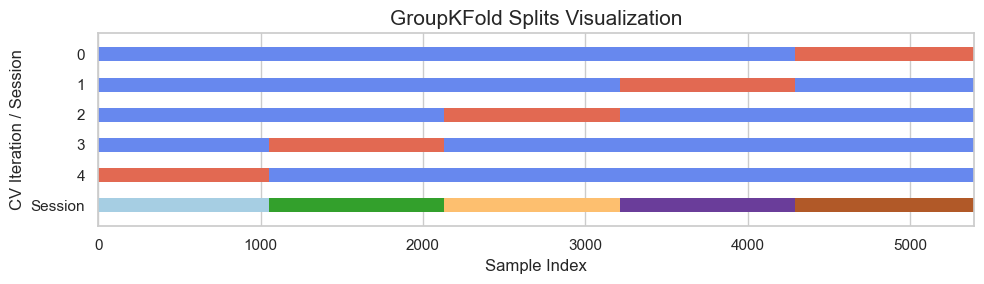

In [22]:

# %% [markdown]
# ## 6. Cross-Validation Strategy (Freemoves)
#
# Using `GroupKFold` with session IDs.

# %%
N_SPLITS_FREE = N_SESSIONS_TRAIN_VAL_FREE # Should be 5
cv_strategy_free = GroupKFold(n_splits=N_SPLITS_FREE)
print(f"Using GroupKFold with {N_SPLITS_FREE} splits for Freemoves.")

# Plotting function (same as before)
def plot_cv_indices(cv, X, y, group, n_splits):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired; cmap_cv = plt.cm.coolwarm
    # Generate splits and plot
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan] * len(X)); indices[test_idx] = 1; indices[train_idx] = 0
        # Plotting the splits for each CV iteration
        ax.scatter(range(len(indices)), [i + .5] * len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    # Plotting the session groups
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    # Formatting the plot
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration / Session", ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15); plt.tight_layout(); plt.show()
    
# Plot for freemoves setup
if 'X_features_free' in locals() and X_features_free.size > 0:
    plot_cv_indices(cv_strategy_free, X_features_free, y_windowed_free, groups_free, N_SPLITS_FREE)
else:
    print("Skipping CV plot: Freemoves features not available.")


In [23]:

# %% [markdown]
# ## 7. Baseline Model Training and Evaluation (Freemoves - All Features)
#
# Evaluate Ridge, Lasso, RF using all features on the freemoves data. **Using correct 51-dim target.**

# %%
# Performance Metrics & Scorers (same definitions)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.maximum(mean_squared_error(y_true, y_pred), 0))

def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0, keepdims=True)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    if denominator < 1e-9: return 0.0 if numerator < 1e-9 else np.inf
    else: return numerator / denominator

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}
print("Scorers defined: RMSE (neg), NMSE (neg), R2.")
# Select Baseline Models (same models, new instances via clone later)
model_ridge_base = Ridge(alpha=1.0)
model_lasso_base = Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42)
model_rf_base = RandomForestRegressor(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
baseline_models_to_evaluate_free = {"Ridge": model_ridge_base, "Lasso": model_lasso_base, "RandomForest": model_rf_base}

# Store freemoves results
all_cv_results_free = {}
results_summary_list_free = []

# %%
# Evaluate baseline models on FREEMOVES data with ALL features
print("--- Evaluating Baseline Models (Freemoves - ALL Features) ---")
cv_params_free = {'groups': groups_free}

for model_name, model in baseline_models_to_evaluate_free.items():
    with timer(f"Cross-validating {model_name} (freemoves, all features)"):
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # All features
            ('scaling', StandardScaler()),
            ('regression', clone(model)) # Clone model for safety
        ])
        # Perform cross-validation using freemoves data and CORRECT target
        try:
             scores = cross_validate(
                 pipeline, X_windowed_free, y_windowed_free, # Use freemoves data
                 cv=cv_strategy_free, scoring=scorers, n_jobs=-1,
                 return_train_score=False, params=cv_params_free, error_score='raise'
             )
        except TypeError as e:
             # Fallback loop (same logic, just using _free variables)
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed, using manual loop...")
                fold_scores = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free)):
                    start_fit_time = time.time()
                    pipeline.fit(X_windowed_free[train_idx], y_windowed_free[train_idx])
                    end_fit_time = time.time()
                    y_pred = pipeline.predict(X_windowed_free[test_idx])
                    end_score_time = time.time()
                    fold_scores['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                        score_value = scorer_func(pipeline, X_windowed_free[test_idx], y_windowed_free[test_idx])
                        fold_scores[score_name].append(score_value)
                scores = {f"test_{key}": np.array(values) for key, values in fold_scores.items() if key in scorers}
                scores['fit_time'] = np.array(fold_scores['fit_time'])
                scores['score_time'] = np.array(fold_scores['score_time'])
            else: raise e
        all_cv_results_free[model_name] = scores

# %%
# Display Freemoves Baseline CV Results (All Features)
print("\nFreemoves Baseline CV Performance Results (All Features):")
for model_name, scores in all_cv_results_free.items():
     if model_name in baseline_models_to_evaluate_free:
        mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
        mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
        mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
        fit_time_mean = np.nanmean(scores['fit_time']); score_time_mean = np.nanmean(scores['score_time'])
        print(f"\n--- {model_name} (Freemoves - All Features) ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}") # Check if R2 makes sense now
        print(f"  Avg Fit Time: {fit_time_mean:.2f}s"); print(f"  Avg Score Time: {score_time_mean:.2f}s")
        results_summary_list_free.append({'Model': model_name, 'Type': 'Baseline_AllFeat_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

results_df_free = pd.DataFrame(results_summary_list_free)
print("\n--- Freemoves Baseline Summary Table (All Features) ---")
if not results_df_free.empty: print(results_df_free[results_df_free['Type'] == 'Baseline_AllFeat_Free'].to_string(index=False, float_format="%.4f"))
else: print("Results DataFrame is empty.")

Scorers defined: RMSE (neg), NMSE (neg), R2.
--- Evaluating Baseline Models (Freemoves - ALL Features) ---
Cross-validating Ridge (freemoves, all features)...
Cross-validating Ridge (freemoves, all features) done in 34.79 seconds.

Cross-validating Lasso (freemoves, all features)...
Cross-validating Lasso (freemoves, all features) done in 50.68 seconds.

Cross-validating RandomForest (freemoves, all features)...
Cross-validating RandomForest (freemoves, all features) done in 102.56 seconds.


Freemoves Baseline CV Performance Results (All Features):

--- Ridge (Freemoves - All Features) ---
  RMSE: 10.9835 +/- 1.3112
  NMSE: 0.8587 +/- 0.1480
  R2 Score: -0.0047 +/- 0.1439
  Avg Fit Time: 21.17s
  Avg Score Time: 3.11s

--- Lasso (Freemoves - All Features) ---
  RMSE: 10.9395 +/- 1.2890
  NMSE: 0.8511 +/- 0.1394
  R2 Score: 0.0007 +/- 0.1239
  Avg Fit Time: 37.05s
  Avg Score Time: 5.50s

--- RandomForest (Freemoves - All Features) ---
  RMSE: 10.6926 +/- 1.8213
  NMSE: 0.8071 +/- 0.16


--- RF Feature Importance Analysis (Freemoves Full Data - Insight) ---
Extracting & Scaling Freemoves features for Full Importance Analysis...
Extracting & Scaling Freemoves features for Full Importance Analysis done in 12.04 seconds.

Training RF on full freemoves scaled data for Importance Plot...
Training RF on full freemoves scaled data for Importance Plot done in 10.22 seconds.


Freemoves RF Feature Importances (Top 30 - full data):


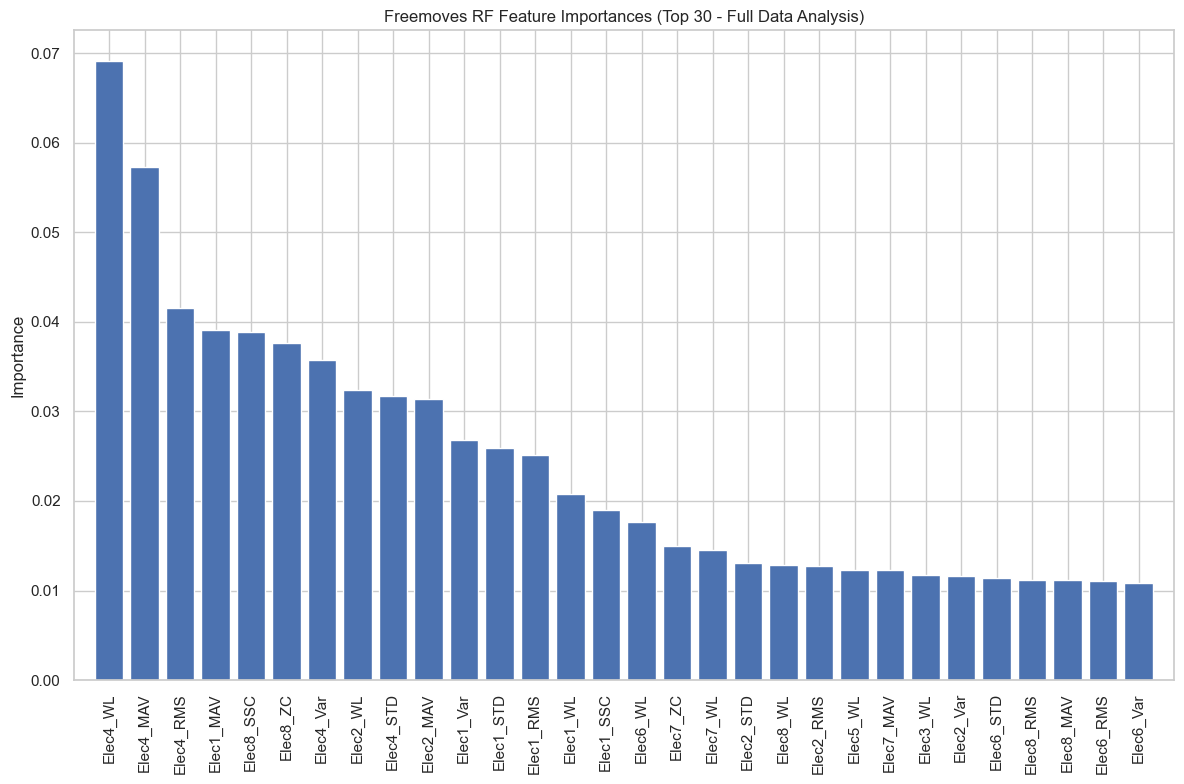


--- Evaluating Models with Integrated Feature Selection (Freemoves - Nested CV) ---

--- Processing Freemoves Fold 1/5 ---
  Fold 1: Feature Extraction...
  Fold 1: Feature Extraction done in 10.05 seconds.

  Fold 1: Scaling...
  Fold 1: Scaling done in 0.01 seconds.

  Fold 1: RFECV (estimator=Ridge, n_jobs=1)...
    RFECV selected 49 features.
  Fold 1: RFECV (estimator=Ridge, n_jobs=1) done in 0.56 seconds.

  Fold 1: Importance Selection (estimator=RF)...
    Importance selected top 32 features.
  Fold 1: Importance Selection (estimator=RF) done in 3.69 seconds.

  Fold 1: Evaluating Ridge_RFECV...
    Ridge_RFECV - RMSE: 9.4018, NMSE: 0.7944, R2: -0.0468
  Fold 1: Evaluating Ridge_RFECV done in 0.02 seconds.

  Fold 1: Evaluating RF_Importance...
    RF_Importance - RMSE: 9.2928, NMSE: 0.7761, R2: -0.0206
  Fold 1: Evaluating RF_Importance done in 8.60 seconds.

  Fold 1: Evaluating Ridge_Importance...
    Ridge_Importance - RMSE: 9.8108, NMSE: 0.8650, R2: -0.1041
  Fold 1: Eval

In [24]:
# %% [markdown]
# ## 8. Feature Importance Analysis and Integrated Selection (Freemoves)
#
# Perform analysis and integrated selection for the freemoves dataset. Expect longer runtimes.

# %%
# --- Feature Importance Analysis (Freemoves Data - for Insight) ---
print("\n--- RF Feature Importance Analysis (Freemoves Full Data - Insight) ---")
analysis_pipeline_full_free = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler())])
with timer("Extracting & Scaling Freemoves features for Full Importance Analysis"):
    X_features_scaled_full_free = analysis_pipeline_full_free.fit_transform(X_windowed_free, y_windowed_free)
    feature_names_full_free = analysis_pipeline_full_free.named_steps['feature_extraction'].get_feature_names_out()
with timer("Training RF on full freemoves scaled data for Importance Plot"):
    model_rf_analysis_free = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
    model_rf_analysis_free.fit(X_features_scaled_full_free, y_windowed_free)
importances_full_free = model_rf_analysis_free.feature_importances_
indices_full_free = np.argsort(importances_full_free)[::-1]
print("\nFreemoves RF Feature Importances (Top 30 - full data):")
n_top_features_plot = 30
plt.figure(figsize=(12, 8)); plt.title("Freemoves RF Feature Importances (Top 30 - Full Data Analysis)")
top_indices_free = indices_full_free[:n_top_features_plot]
plt.bar(range(len(top_indices_free)), importances_full_free[top_indices_free], align='center')
plt.xticks(range(len(top_indices_free)), [feature_names_full_free[i] for i in top_indices_free], rotation=90)
plt.xlim([-1, len(top_indices_free)]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()
del X_features_scaled_full_free # Clear memory
gc.collect()


# %% [markdown]
# ### 8.1 Cross-Validation with Integrated Feature Selection (Freemoves - Expanded)

# %%
print("\n--- Evaluating Models with Integrated Feature Selection (Freemoves - Nested CV) ---")
# Settings (same as guided)
MIN_FEATURES_RFECV = 10; STEP_RFECV = 5; CV_INNER_RFECV = 3; N_FEATURES_IMPORTANCE = 32

fs_results_free = {"Ridge_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "RF_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "Ridge_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "RF_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}}
model_ridge_final_free = Ridge(alpha=1.0)
model_rf_final_free = RandomForestRegressor(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
model_ridge_for_rfecv_free = Ridge(alpha=1.0)
model_rf_for_importance_free = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)

fold_num = 0
feature_extractor_cv_free = EMGFeatureExtractor() # New instance

# Outer CV Loop (LOSO) for Freemoves
for train_idx, test_idx in cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free):
    fold_num += 1
    print(f"\n--- Processing Freemoves Fold {fold_num}/{N_SPLITS_FREE} ---")
    start_fold_time = time.time()
    # 1. Split raw windowed data
    X_train_fold_raw, X_test_fold_raw = X_windowed_free[train_idx], X_windowed_free[test_idx]
    y_train_fold, y_test_fold = y_windowed_free[train_idx], y_windowed_free[test_idx]
    # 2. Extract features
    with timer(f"  Fold {fold_num}: Feature Extraction"):
        X_train_features = feature_extractor_cv_free.transform(X_train_fold_raw)
        X_test_features = feature_extractor_cv_free.transform(X_test_fold_raw)
        if fold_num == 1: feature_names_free = feature_extractor_cv_free.get_feature_names_out()
    # 3. Scale features
    with timer(f"  Fold {fold_num}: Scaling"):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_test_scaled = scaler.transform(X_test_features)
    # --- Feature Selection Step ---
    selected_indices_rfecv = None; n_features_rfecv = X_train_scaled.shape[1]
    selected_indices_importance = None; n_features_importance = X_train_scaled.shape[1]
    # 4a. RFECV (n_jobs=1) - **EXPECT THIS TO BE SLOW**
    with timer(f"  Fold {fold_num}: RFECV (estimator=Ridge, n_jobs=1)"):
        try:
            rfecv_selector = RFECV(estimator=clone(model_ridge_for_rfecv_free), step=STEP_RFECV, cv=CV_INNER_RFECV, scoring=scorers['rmse'], min_features_to_select=MIN_FEATURES_RFECV, n_jobs=1)
            rfecv_selector.fit(X_train_scaled, y_train_fold) # Fit requires correct target shape
            selected_indices_rfecv = rfecv_selector.support_; n_features_rfecv = rfecv_selector.n_features_
            print(f"    RFECV selected {n_features_rfecv} features.")
        except Exception as e: print(f"    RFECV failed: {e}. Using all."); selected_indices_rfecv = np.ones(X_train_scaled.shape[1], dtype=bool)
    # 4b. Importance Thresholding
    with timer(f"  Fold {fold_num}: Importance Selection (estimator=RF)"):
        try:
            rf_importance_model = clone(model_rf_for_importance_free)
            rf_importance_model.fit(X_train_scaled, y_train_fold) # Fit requires correct target shape
            importances = rf_importance_model.feature_importances_
            indices_sorted = np.argsort(importances)[::-1]
            selected_indices_importance = np.zeros(X_train_scaled.shape[1], dtype=bool)
            n_select = min(N_FEATURES_IMPORTANCE, X_train_scaled.shape[1])
            selected_indices_importance[indices_sorted[:n_select]] = True; n_features_importance = n_select
            print(f"    Importance selected top {n_features_importance} features.")
        except Exception as e: print(f"    Importance failed: {e}. Using all."); selected_indices_importance = np.ones(X_train_scaled.shape[1], dtype=bool)
    # --- Model Evaluation Step ---
    def evaluate_model_free(model_key, model_instance, X_train, y_train, X_test, y_test, selected_indices, n_features):
        results_dict = fs_results_free # Use the freemoves results dict
        if selected_indices is None or not np.any(selected_indices): print(f"    Skipping {model_key}"); results_dict[model_key]['test_rmse'].append(np.nan); results_dict[model_key]['test_nmse'].append(np.nan); results_dict[model_key]['test_r2'].append(np.nan); results_dict[model_key]['n_features'].append(X_train.shape[1]); return
        X_train_sel = X_train[:, selected_indices]; X_test_sel = X_test[:, selected_indices]
        model_instance = clone(model_instance)
        model_instance.fit(X_train_sel, y_train) # Fit requires correct target shape
        y_pred = model_instance.predict(X_test_sel)
        rmse = root_mean_squared_error(y_test, y_pred); nmse = normalized_mean_squared_error(y_test, y_pred); r2 = r2_score(y_test, y_pred)
        results_dict[model_key]['test_rmse'].append(-rmse); results_dict[model_key]['test_nmse'].append(-nmse); results_dict[model_key]['test_r2'].append(r2); results_dict[model_key]['n_features'].append(n_features)
        print(f"    {model_key} - RMSE: {rmse:.4f}, NMSE: {nmse:.4f}, R2: {r2:.4f}")

    fold_eval_start_time = time.time()
    with timer(f"  Fold {fold_num}: Evaluating Ridge_RFECV"): evaluate_model_free("Ridge_RFECV", model_ridge_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)
    with timer(f"  Fold {fold_num}: Evaluating RF_Importance"): evaluate_model_free("RF_Importance", model_rf_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)
    with timer(f"  Fold {fold_num}: Evaluating Ridge_Importance"): evaluate_model_free("Ridge_Importance", model_ridge_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)
    with timer(f"  Fold {fold_num}: Evaluating RF_RFECV"): evaluate_model_free("RF_RFECV", model_rf_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)
    # Record Timings
    fold_end_time = time.time(); total_fold_time = fold_end_time - start_fold_time
    for key in fs_results_free: fs_results_free[key]['fit_time'].append(total_fold_time); fs_results_free[key]['score_time'].append(0)
    # Clean up memory
    del X_train_fold_raw, X_test_fold_raw, y_train_fold, y_test_fold, X_train_features, X_test_features, X_train_scaled, X_test_scaled
    gc.collect()

# %%
# Aggregate and Display Freemoves FS Results
print("\n--- Freemoves Performance Results (Integrated Feature Selection - Expanded) ---")
results_summary_list_free = [item for item in results_summary_list_free if item['Type'] != 'Baseline_FS_Free'] # Clear previous FS results for freemoves
for model_fs_name, scores in fs_results_free.items():
    if not scores['test_rmse']: print(f"Warning: No scores for {model_fs_name}."); continue
    mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
    mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
    mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
    fit_time_mean = np.nanmean(scores['fit_time']); avg_n_features = np.nanmean(scores['n_features']); std_n_features = np.nanstd(scores['n_features'])
    print(f"\n--- {model_fs_name} (Freemoves) ---")
    print(f"  Avg. Features Selected: {avg_n_features:.1f} +/- {std_n_features:.1f}")
    print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}"); print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
    print(f"  Avg Total Time per Fold: {fit_time_mean:.2f}s")
    results_summary_list_free.append({'Model': model_fs_name, 'Type': 'Baseline_FS_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

results_df_free = pd.DataFrame(results_summary_list_free)
print("\n--- Freemoves Updated Summary Table (Including Integrated FS) ---")
if not results_df_free.empty: print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Results DataFrame is empty.")

In [25]:


# %% [markdown]
# ## 9. Sophisticated Approach: Neural Network (Freemoves)
#
# Evaluate the MLP on the freemoves dataset.

# %%
# NN Architecture & Training Functions (same definitions)
class EMG_NN(nn.Module):
    def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
        super(EMG_NN, self).__init__()
        self.layer_1 = nn.Linear(n_features, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.batchnorm1 = nn.BatchNorm1d(hidden_dim1) # Added BatchNorm
        self.dropout1 = nn.Dropout(dropout_p)
        self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.batchnorm2 = nn.BatchNorm1d(hidden_dim2) # Added BatchNorm
        self.dropout2 = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_dim2, n_joints)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.batchnorm1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.batchnorm2(self.layer_2(x))))
        x = self.output_layer(x)
        return x

# %%
# Training and Evaluation Functions for PyTorch NN (Copied from original GEGE)

def train_nn_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad() # Zero gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, targets) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        running_loss += loss.item() * inputs.size(0) # Accumulate loss

    return running_loss / len(dataloader.dataset) # Return average loss for the epoch

def evaluate_nn_model(model, dataloader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad(): # Disable gradient calculations
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, targets) # Calculate loss
            running_loss += loss.item() * inputs.size(0) # Accumulate loss
            all_preds.append(outputs.cpu().numpy()) # Collect predictions (move back to CPU)
            all_targets.append(targets.cpu().numpy()) # Collect targets

    avg_loss = running_loss / len(dataloader.dataset)
    # Concatenate predictions and targets from all batches
    predictions = np.concatenate(all_preds)
    true_values = np.concatenate(all_targets)
    return avg_loss, predictions, true_values

# %%
# Manual Cross-Validation Loop for Neural Network (Freemoves)
# Hyperparameters (start with same as guided, might need tuning)
N_EPOCHS_FREE = 75; BATCH_SIZE_FREE = 64; LEARNING_RATE_FREE = 0.001; WEIGHT_DECAY_FREE = 1e-5

# Ensure X_features_free exists
if 'X_features_free' not in locals(): raise RuntimeError("X_features_free not available.")
X_input_for_nn_cv_free = X_features_free
n_input_features_free = X_input_for_nn_cv_free.shape[1]

nn_cv_scores_free = {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': []}
print(f"\n--- Evaluating Neural Network (Freemoves - Manual CV, Input Features: {n_input_features_free}) ---")

fold_num = 0
for train_idx, val_idx in cv_strategy_free.split(X_input_for_nn_cv_free, y_windowed_free, groups=groups_free):
    fold_num += 1
    print(f"\nStarting Freemoves NN CV Fold {fold_num}/{N_SPLITS_FREE}")
    start_fold_time = time.time()
    # 1. Split data
    X_train_fold, X_val_fold = X_input_for_nn_cv_free[train_idx], X_input_for_nn_cv_free[val_idx]
    y_train_fold, y_val_fold = y_windowed_free[train_idx], y_windowed_free[val_idx]
    # 2. Scale features
    scaler_nn_fold = StandardScaler(); X_train_fold_scaled = scaler_nn_fold.fit_transform(X_train_fold); X_val_fold_scaled = scaler_nn_fold.transform(X_val_fold)
    # 3. Datasets & DataLoaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold)); val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_FREE, shuffle=True, num_workers=2, pin_memory=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_FREE*2, shuffle=False, num_workers=2, pin_memory=True)
    # 4. Initialize model, loss, optimizer
    model_nn = EMG_NN(n_features=n_input_features_free, n_joints=N_JOINTS).to(device)
    criterion = nn.MSELoss(); optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE_FREE, weight_decay=WEIGHT_DECAY_FREE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=False) # Less verbose scheduler
    # 5. Training loop
    best_val_loss = float('inf'); epochs_no_improve = 0; patience = 15
    print(f"Fold {fold_num}: Training for up to {N_EPOCHS_FREE} epochs...")
    for epoch in range(N_EPOCHS_FREE):
        train_loss = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        val_loss_epoch, _, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)
        if (epoch + 1) % 25 == 0 or epoch == N_EPOCHS_FREE - 1: print(f'  Epoch {epoch+1}/{N_EPOCHS_FREE}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss_epoch:.6f}')
        scheduler.step(val_loss_epoch)
        if val_loss_epoch < best_val_loss: best_val_loss = val_loss_epoch; epochs_no_improve = 0
        else: epochs_no_improve += 1
        if epochs_no_improve >= patience: print(f"  Early stopping @ epoch {epoch + 1}"); break
    fit_end_time = time.time()
    # 6. Evaluate
    print(f"Fold {fold_num}: Evaluating..."); _, y_pred_fold, y_true_fold = evaluate_nn_model(model_nn, val_loader, criterion, device); score_end_time = time.time()
    # 7. Calculate metrics
    rmse_fold = root_mean_squared_error(y_true_fold, y_pred_fold); nmse_fold = normalized_mean_squared_error(y_true_fold, y_pred_fold); r2_fold = r2_score(y_true_fold, y_pred_fold)
    nn_cv_scores_free['test_rmse'].append(-rmse_fold); nn_cv_scores_free['test_nmse'].append(-nmse_fold); nn_cv_scores_free['test_r2'].append(r2_fold)
    nn_cv_scores_free['fit_time'].append(fit_end_time - start_fold_time); nn_cv_scores_free['score_time'].append(score_end_time - fit_end_time)
    print(f"Fold {fold_num} Metrics: RMSE={rmse_fold:.4f}, NMSE={nmse_fold:.4f}, R2={r2_fold:.4f}")
    del model_nn, train_loader, val_loader, train_dataset, val_dataset; gc.collect(); torch.cuda.empty_cache()

# Store overall NN results for freemoves
all_cv_results_free["NeuralNetwork_Free"] = nn_cv_scores_free

# %%
# Add Freemoves NN results to summary DataFrame
nn_model_name_free = "NeuralNetwork_Free"
if nn_model_name_free in all_cv_results_free:
    nn_scores = all_cv_results_free[nn_model_name_free]
    mean_rmse = -np.nanmean(nn_scores['test_rmse']); std_rmse = np.nanstd(nn_scores['test_rmse'])
    mean_nmse = -np.nanmean(nn_scores['test_nmse']); std_nmse = np.nanstd(nn_scores['test_nmse'])
    mean_r2 = np.nanmean(nn_scores['test_r2']); std_r2 = np.nanstd(nn_scores['test_r2'])
    fit_time_mean = np.nanmean(nn_scores['fit_time'])
    results_summary_list_free.append({'Model': nn_model_name_free, 'Type': 'Sophisticated_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})
    results_df_free = pd.DataFrame(results_summary_list_free)
    print("\n--- Freemoves Combined Model Comparison Table (incl. NN) ---")
    print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Freemoves Neural Network results not found.")


--- Evaluating Neural Network (Freemoves - Manual CV, Input Features: 64) ---

Starting Freemoves NN CV Fold 1/5
Fold 1: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 89.016741, Val Loss: 82.363778
  Epoch 50/75, Train Loss: 81.512891, Val Loss: 80.652288
  Epoch 75/75, Train Loss: 74.918211, Val Loss: 76.912787
Fold 1: Evaluating...
Fold 1 Metrics: RMSE=8.7700, NMSE=0.6912, R2=-6184881.0000

Starting Freemoves NN CV Fold 2/5
Fold 2: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 87.067882, Val Loss: 81.210352
  Epoch 50/75, Train Loss: 77.391130, Val Loss: 78.670059
  Epoch 75/75, Train Loss: 71.563714, Val Loss: 75.037527
Fold 2: Evaluating...
Fold 2 Metrics: RMSE=8.6624, NMSE=0.6400, R2=-4839587.0000

Starting Freemoves NN CV Fold 3/5
Fold 3: Training for up to 75 epochs...


...

  Epoch 25/75, Train Loss: 82.295268, Val Loss: 102.218647
  Epoch 50/75, Train Loss: 74.540617, Val Loss: 99.771999
  Early stopping @ epoch 74
Fold 3: Evaluating...
Fold 3 Metrics: RMSE=9.9667, NMSE=0.5719, R2=-6505961.0000

Starting Freemoves NN CV Fold 4/5
Fold 4: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 78.360104, Val Loss: 140.502889
  Early stopping @ epoch 40
Fold 4: Evaluating...
Fold 4 Metrics: RMSE=12.2587, NMSE=0.8211, R2=-17219138.0000

Starting Freemoves NN CV Fold 5/5
Fold 5: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 84.268917, Val Loss: 108.058422
  Early stopping @ epoch 35
Fold 5: Evaluating...
Fold 5 Metrics: RMSE=10.4509, NMSE=0.8218, R2=-9008559.0000

--- Freemoves Combined Model Comparison Table (incl. NN) ---
             Model                  Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std       R2_mean       R2_std   FitTime
NeuralNetwork_Free    Sophisticated_Free    10.0217    1.3119     0.7092    0.0991 -8751625.2000 4442972.3015 1054.8560
      RandomForest Baseline_AllFeat_Free    10.6926    1.8213     0.8071    0.1632        0.0535       0.1761   94.3101
          RF_RFECV      Baseline_FS_Free    10.7509    1.8949     0.8163    0.1748        0.0466       0.1854   38.3725
     RF_Importance      Baseline_FS_Free    10.8373    1.9174     0.8302    0.1812        0.0373       0.1851   38.3725
             Lasso Baseline_AllFeat_Free    10.9395    1.2890     0.8511    0.1394        0.0007       0.1239   37.0461
       Ridge_RFECV      Baseline_FS_Free    10.94

In [ ]:


# %% [markdown]
# ## 10. Objective 6: Ensembling Strategies (Freemoves)
#
# Implement Averaging and Stacking for the freemoves dataset.

# %% [markdown]
# ### 10.1 Generate Out-of-Fold (OOF) Predictions (Freemoves)

# %%
oof_predictions_free = {} # Dictionary for freemoves OOF predictions

# --- OOF for Baselines (All Features) ---
print("--- Generating OOF Predictions (Freemoves - Baselines All Features) ---")
baseline_pipelines_oof_free = {}
for model_name, model in baseline_models_to_evaluate_free.items(): # Use freemoves models
     baseline_pipelines_oof_free[model_name] = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', clone(model))])
for model_name, pipeline in baseline_pipelines_oof_free.items():
     with timer(f"Generating OOF predictions for {model_name} (Freemoves)"):
         try: # Use freemoves data
              oof_preds = cross_val_predict(pipeline, X_windowed_free, y_windowed_free, cv=cv_strategy_free, n_jobs=-1, method='predict', params={'groups': groups_free})
         except TypeError as e: # Fallback
             if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                  print("Metadata routing failed, using manual loop...")
                  oof_preds_list = [None] * len(X_windowed_free)
                  for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free)):
                      pipeline.fit(X_windowed_free[train_idx], y_windowed_free[train_idx])
                      fold_preds = pipeline.predict(X_windowed_free[test_idx])
                      for i, idx in enumerate(test_idx): oof_preds_list[idx] = fold_preds[i]
                  oof_preds = np.stack(oof_preds_list)
             else: raise e
         oof_predictions_free[model_name] = oof_preds
     print(f"Shape of {model_name} Freemoves OOF predictions: {oof_preds.shape}")

# --- OOF for Neural Network (Freemoves) ---
print("\n--- Generating OOF Predictions (Freemoves - Neural Network) ---")
N_EPOCHS_OOF_FREE = 75; BATCH_SIZE_OOF_FREE = 64; LEARNING_RATE_OOF_FREE = 0.001; WEIGHT_DECAY_OOF_FREE = 1e-5
nn_oof_preds_list_free = [None] * len(X_input_for_nn_cv_free)
if 'X_input_for_nn_cv_free' not in locals(): raise ValueError("NN features (freemoves) not found.")
n_input_features_oof_free = X_input_for_nn_cv_free.shape[1]
fold_num = 0
with timer("Generating OOF predictions for NN (Freemoves - Manual CV)"):
    for train_idx, val_idx in cv_strategy_free.split(X_input_for_nn_cv_free, y_windowed_free, groups=groups_free):
        fold_num += 1; print(f"  Processing NN OOF Fold {fold_num}/{N_SPLITS_FREE}") # Print progress
        # 1. Split data
        X_train_fold, X_val_fold = X_input_for_nn_cv_free[train_idx], X_input_for_nn_cv_free[val_idx]; y_train_fold, y_val_fold = y_windowed_free[train_idx], y_windowed_free[val_idx]
        # 2. Scale features
        scaler_oof = StandardScaler(); X_train_fold_scaled = scaler_oof.fit_transform(X_train_fold); X_val_fold_scaled = scaler_oof.transform(X_val_fold)
        # 3. Datasets & DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold)); val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_OOF_FREE, shuffle=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_OOF_FREE*2, shuffle=False)
        # 4. Initialize model, loss, optimizer
        model_nn_oof = EMG_NN(n_features=n_input_features_oof_free, n_joints=N_JOINTS).to(device); criterion = nn.MSELoss(); optimizer = optim.Adam(model_nn_oof.parameters(), lr=LEARNING_RATE_OOF_FREE, weight_decay=WEIGHT_DECAY_OOF_FREE)
        # 5. Training loop
        for epoch in range(N_EPOCHS_OOF_FREE): _ = train_nn_epoch(model_nn_oof, train_loader, criterion, optimizer, device)
        # 6. Evaluate & GET PREDICTIONS
        _, y_pred_fold, _ = evaluate_nn_model(model_nn_oof, val_loader, criterion, device)
        # 7. Store predictions
        for i, idx in enumerate(val_idx):
             if idx < len(nn_oof_preds_list_free): nn_oof_preds_list_free[idx] = y_pred_fold[i]
             else: print(f"Warning: Index {idx} out of bounds for list size {len(nn_oof_preds_list_free)}")
        # Clean up
        del model_nn_oof, train_loader, val_loader, train_dataset, val_dataset; gc.collect(); torch.cuda.empty_cache()

# Combine NN OOF predictions
contains_none = any(pred is None for pred in nn_oof_preds_list_free)
if contains_none:
    print("Warning: Filling missing NN OOF preds (Freemoves) with zeros.")
    shapes = [p.shape for p in nn_oof_preds_list_free if p is not None]; avg_shape = shapes[0] if shapes else (N_JOINTS,)
    fill_value = np.zeros(avg_shape); nn_oof_preds_filled = [p if p is not None else fill_value for p in nn_oof_preds_list_free]
    oof_predictions_free["NeuralNetwork"] = np.stack(nn_oof_preds_filled)
else: oof_predictions_free["NeuralNetwork"] = np.stack(nn_oof_preds_list_free)

print(f"Shape of NN Freemoves OOF predictions: {oof_predictions_free['NeuralNetwork'].shape}")
# Verification
ensemble_model_names_free = list(baseline_models_to_evaluate_free.keys()) + ["NeuralNetwork"]
missing_oof_free = [name for name in ensemble_model_names_free if name not in oof_predictions_free]
if missing_oof_free: raise RuntimeError(f"Missing Freemoves OOF predictions for: {missing_oof_free}")

# %% [markdown]
# ### 10.2 Averaging Ensemble (Freemoves)

# %%
print("\n--- Evaluating Averaging Ensemble (Freemoves) ---")
model_names_for_avg_free = list(oof_predictions_free.keys())
print(f"Averaging predictions from models: {model_names_for_avg_free}")
oof_preds_sum_free = np.zeros_like(y_windowed_free, dtype=np.float64)
for model_name in model_names_for_avg_free: oof_preds_sum_free += oof_predictions_free[model_name]
oof_preds_avg_free = oof_preds_sum_free / len(model_names_for_avg_free)
# Evaluate ONCE on full OOF set
avg_rmse = root_mean_squared_error(y_windowed_free, oof_preds_avg_free); avg_nmse = normalized_mean_squared_error(y_windowed_free, oof_preds_avg_free); avg_r2 = r2_score(y_windowed_free, oof_preds_avg_free)
print(f"\nAveraging Ensemble Performance (Freemoves OOF):"); print(f"  RMSE: {avg_rmse:.4f}"); print(f"  NMSE: {avg_nmse:.4f}"); print(f"  R2 Score: {avg_r2:.4f}") # Check R2
results_summary_list_free.append({'Model': 'AverageEnsemble_Free', 'Type': 'Ensemble_Free', 'RMSE_mean': avg_rmse, 'RMSE_std': np.nan, 'NMSE_mean': avg_nmse, 'NMSE_std': np.nan, 'R2_mean': avg_r2, 'R2_std': np.nan, 'FitTime': np.nan})
results_df_free = pd.DataFrame(results_summary_list_free)

# %% [markdown]
# ### 10.3 Stacking Ensemble (Freemoves - Multiple Meta-Learners)
# %%
print("\n--- Evaluating Stacking Ensemble (Freemoves - Multiple Meta-Learners) ---")

# 1. Create Meta-Features for Freemoves dataset
recreate_x_meta_free = True # Flag to determine if X_meta_free needs to be created/recreated

# Check if X_meta_free exists, is valid, and matches current y_windowed_free
if 'X_meta_free' in locals() and X_meta_free is not None:
    if isinstance(X_meta_free, np.ndarray) and X_meta_free.shape[0] == len(y_windowed_free):
        print("Using existing freemoves meta-features (X_meta_free).")
        # Ensure model_names_for_stacking_free is available if reusing X_meta_free
        if 'model_names_for_stacking_free' not in locals() or not model_names_for_stacking_free:
             model_names_for_stacking_free = list(oof_predictions_free.keys())
        recreate_x_meta_free = False
    elif not isinstance(X_meta_free, np.ndarray):
        print(f"X_meta_free exists but is not a NumPy array (type: {type(X_meta_free)}). Recreating freemoves meta-features...")
    else: # Exists, is an ndarray, but shape is wrong
        print(f"X_meta_free shape ({X_meta_free.shape[0]}) mismatch with y_windowed_free ({len(y_windowed_free)}). Recreating freemoves meta-features...")
elif 'X_meta_free' in locals() and X_meta_free is None:
    print("X_meta_free is None. Recreating freemoves meta-features...")
else: # 'X_meta_free' not in locals()
    print("X_meta_free not found. Creating freemoves meta-features...")

if recreate_x_meta_free:
    if 'oof_predictions_free' not in locals() or not oof_predictions_free:
        raise RuntimeError("oof_predictions_free dictionary is missing or empty. Cannot create X_meta_free. Please run OOF generation for Freemoves first.")

    model_names_for_stacking_free = list(oof_predictions_free.keys())
    X_meta_list_free = []

    print("Preparing to create X_meta_free from Freemoves OOF predictions:")
    for model_name in model_names_for_stacking_free:
        pred = oof_predictions_free.get(model_name)
        if pred is None:
            raise ValueError(f"Freemoves OOF prediction for model '{model_name}' is None. Cannot create X_meta_free. Check Freemoves OOF generation.")
        if not isinstance(pred, np.ndarray):
            raise TypeError(f"Freemoves OOF prediction for model '{model_name}' is not a NumPy array (type: {type(pred)}).")
        if pred.shape[0] != len(y_windowed_free):
            raise ValueError(f"Freemoves OOF prediction for model '{model_name}' has incorrect samples ({pred.shape[0]}) vs y_windowed_free ({len(y_windowed_free)}).")
        print(f"  Freemoves OOF for {model_name}: shape={pred.shape}, type={type(pred)}")
        X_meta_list_free.append(pred)

    if not X_meta_list_free:
        raise ValueError("X_meta_list_free is empty (no valid Freemoves OOF predictions found to stack).")

    try:
        X_meta_free = np.hstack(X_meta_list_free)
        print(f"Successfully created Freemoves Meta-Features (X_meta_free). Shape: {X_meta_free.shape}")
    except (ValueError, TypeError) as e:
        print(f"Error stacking Freemoves OOF predictions: {e}")
        print("Details of arrays in X_meta_list_free that were attempted to stack:")
        for i, arr_in_list in enumerate(X_meta_list_free):
            m_name = model_names_for_stacking_free[i] if i < len(model_names_for_stacking_free) else "Unknown"
            print(f"  Model {m_name}: type={type(arr_in_list)}, shape={getattr(arr_in_list, 'shape', 'N/A')}")
        X_meta_free = None # Ensure X_meta_free is None if stacking fails
        raise

# Final check after creation/reuse attempt
if X_meta_free is None:
    raise RuntimeError("X_meta_free is None after creation/reuse attempt. Cannot proceed with Freemoves Stacking Ensemble.")
if not isinstance(X_meta_free, np.ndarray) or X_meta_free.shape[0] != len(y_windowed_free):
     raise RuntimeError(f"X_meta_free is invalid or shape mismatch. Shape: {getattr(X_meta_free, 'shape', 'N/A')}, Expected samples: {len(y_windowed_free)}")


# 2. Define Meta-Learners (similar names, ensure they are distinct if needed or just reuse definitions)
meta_learners_free = {
    "Stacking_Ridge_Free": Ridge(alpha=1.0),
    "Stacking_Lasso_Free": Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42),
    "Stacking_RF_Free": RandomForestRegressor(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42, max_features=0.5)
}

# 3. Cross-Validate each Meta-Learner on Freemoves data
for meta_name, meta_model in meta_learners_free.items():
    print(f"\n--- Cross-validating Meta-Learner: {meta_name} ---")
    with timer(f"Cross-validating {meta_name}"):
        stacking_pipeline = Pipeline([('meta_regression', clone(meta_model))]) # Clone meta-model
        try:
            stacking_scores = cross_validate(
                stacking_pipeline, X_meta_free, y_windowed_free, cv=cv_strategy_free,
                scoring=scorers, n_jobs=-1, return_train_score=False,
                params={'groups': groups_free}, error_score='raise'
            )
        except TypeError as e:
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed for freemoves stacking CV, using manual loop...")
                fold_scores_stack = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_meta_free, y_windowed_free, groups=groups_free)):
                    start_fit_time = time.time()
                    stacking_pipeline.fit(X_meta_free[train_idx], y_windowed_free[train_idx])
                    end_fit_time = time.time()
                    y_pred_meta = stacking_pipeline.predict(X_meta_free[test_idx])
                    end_score_time = time.time()

                    fold_scores_stack['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores_stack['score_time'].append(end_score_time - end_fit_time) # This was correct
                    for score_name, scorer_func in scorers.items():
                        # Corrected scoring for manual loop
                        if hasattr(scorer_func, '_score_func'):
                             score_value = scorer_func._score_func(y_windowed_free[test_idx], y_pred_meta, **scorer_func._kwargs)
                             if not scorer_func._sign > 0: # if greater_is_better is False
                                 score_value *= -1
                        else:
                             score_value = scorer_func(y_windowed_free[test_idx], y_pred_meta)
                        fold_scores_stack[score_name].append(score_value)

                stacking_scores = {f"test_{key}": np.array(values) for key, values in fold_scores_stack.items() if key in scorers}
                stacking_scores['fit_time'] = np.array(fold_scores_stack['fit_time'])
                stacking_scores['score_time'] = np.array(fold_scores_stack['score_time'])
            else:
                raise e

        all_cv_results_free[meta_name] = stacking_scores
        mean_rmse = -np.nanmean(stacking_scores['test_rmse'])
        std_rmse = np.nanstd(stacking_scores['test_rmse'])
        mean_nmse = -np.nanmean(stacking_scores['test_nmse'])
        std_nmse = np.nanstd(stacking_scores['test_nmse'])
        mean_r2 = np.nanmean(stacking_scores['test_r2'])
        std_r2 = np.nanstd(stacking_scores['test_r2'])
        fit_time_mean = np.nanmean(stacking_scores['fit_time'])

        print(f"\n{meta_name} Performance (Cross-Validated):")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Meta Fit Time: {fit_time_mean:.2f}s")

        results_summary_list_free.append({
            'Model': meta_name, 'Type': 'Ensemble_Free',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })


results_df_free = pd.DataFrame(results_summary_list_free)
# %% [markdown]
# ### 10.4 Meta-Learner Contribution Analysis (Freemoves - Optional)
#
# Analyze contributions for the best performing *linear* stacking meta-learner on freemoves data.

# %%
print("\n--- Freemoves Stacking Meta-Learner Contribution Analysis ---")
stacking_results_df_free = results_df_free[results_df_free['Model'].str.startswith('Stacking_')]
best_stacking_model_name_free = None
if not stacking_results_df_free.empty:
    try: best_stacking_model_name_free = stacking_results_df_free.loc[stacking_results_df_free['RMSE_mean'].idxmin()]['Model']
    except KeyError: print("Warning: Could not get best freemoves stacking model name.")
is_linear_meta_free = best_stacking_model_name_free and ("Stacking_Ridge" in best_stacking_model_name_free or "Stacking_Lasso" in best_stacking_model_name_free)

if is_linear_meta_free:
    print(f"Analyzing contributions for linear meta-learner: {best_stacking_model_name_free}")
    best_meta_learner_instance_free = meta_learners_free.get(best_stacking_model_name_free)
    if best_meta_learner_instance_free:
        final_meta_pipeline_free = Pipeline([('meta_regression', clone(best_meta_learner_instance_free))])
        final_meta_pipeline_free.fit(X_meta_free, y_windowed_free) # Use freemoves meta features
        meta_regressor_trained_free = final_meta_pipeline_free.named_steps['meta_regression']
        if hasattr(meta_regressor_trained_free, 'coef_'):
            coefficients = meta_regressor_trained_free.coef_
            print(f"Shape of meta-learner coefficients: {coefficients.shape}")
            if coefficients.ndim == 1 and y_windowed_free.ndim > 1 and y_windowed_free.shape[1] > 1: print("Warning: 1D Coefs for multi-output."); avg_mag = np.abs(coefficients)
            elif coefficients.ndim == 2: avg_mag = np.mean(np.abs(coefficients), axis=0)
            else: print("Warning: Unexpected coef dim."); avg_mag = None
            if avg_mag is not None and avg_mag.shape[0] == len(model_names_for_stacking_free) * N_JOINTS:
                avg_coef_magnitudes = {}
                for i, model_name in enumerate(model_names_for_stacking_free):
                    start_col = i * N_JOINTS; end_col = (i + 1) * N_JOINTS
                    avg_coef_magnitudes[model_name] = np.mean(avg_mag[start_col:end_col])
                    print(f"  Avg. Abs. Coef Magnitude for {model_name}: {avg_coef_magnitudes[model_name]:.4f}")
                coef_mag_series = pd.Series(avg_coef_magnitudes).sort_values(ascending=False)
                print("\nRelative Contribution (Freemoves):"); print(coef_mag_series)
                plt.figure(figsize=(8, 4)); coef_mag_series.plot(kind='bar'); plt.title(f'Stacking ({best_stacking_model_name_free}): Base Model Contribution'); plt.ylabel('Avg. Abs. Coef Mag'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
            elif avg_mag is not None: print(f"Warning: Coef shape mismatch {avg_mag.shape[0]} vs {len(model_names_for_stacking_free) * N_JOINTS}")
        else: print(f"{best_stacking_model_name_free} has no 'coef_'.")
    else: print(f"Could not get instance for {best_stacking_model_name_free}")
elif best_stacking_model_name_free: print(f"Best freemoves stacking model ({best_stacking_model_name_free}) is not linear.")
else: print("No best freemoves stacking model identified.")

--- Generating OOF Predictions (Freemoves - Baselines All Features) ---
Generating OOF predictions for Ridge (Freemoves)...
Generating OOF predictions for Ridge (Freemoves) done in 32.60 seconds.

Shape of Ridge Freemoves OOF predictions: (5395, 51)
Generating OOF predictions for Lasso (Freemoves)...
Generating OOF predictions for Lasso (Freemoves) done in 48.30 seconds.

Shape of Lasso Freemoves OOF predictions: (5395, 51)
Generating OOF predictions for RandomForest (Freemoves)...
Generating OOF predictions for RandomForest (Freemoves) done in 90.81 seconds.

Shape of RandomForest Freemoves OOF predictions: (5395, 51)

--- Generating OOF Predictions (Freemoves - Neural Network) ---
Generating OOF predictions for NN (Freemoves - Manual CV)...
  Processing NN OOF Fold 1/5
  Processing NN OOF Fold 2/5
  Processing NN OOF Fold 3/5
  Processing NN OOF Fold 4/5
  Processing NN OOF Fold 5/5
Generating OOF predictions for NN (Freemoves - Manual CV) done in 143.98 seconds.

Shape of NN Freemov

In [27]:


# %% [markdown]
# ## 11. Combined Model Comparison Table (Freemoves - Final)

# %%
print("\n--- Final Combined Freemoves Model Comparison Table ---")
final_summary_free = {}
for item in results_summary_list_free: final_summary_free[item['Model']] = item
unique_results_summary_list_free = list(final_summary_free.values())
results_df_free = pd.DataFrame(unique_results_summary_list_free)
if not results_df_free.empty: print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Freemoves Results DataFrame is empty.")


--- Final Combined Freemoves Model Comparison Table ---
               Model                  Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std         R2_mean       R2_std   FitTime
  NeuralNetwork_Free    Sophisticated_Free    10.0217    1.3119     0.7092    0.0991   -8751625.2000 4442972.3015 1054.8560
AverageEnsemble_Free         Ensemble_Free    10.3598       NaN     0.6704       NaN -192227337.6343          NaN       NaN
    Stacking_RF_Free         Ensemble_Free    10.4174    1.2410     0.7703    0.1164          0.0846       0.1360   53.3375
        RandomForest Baseline_AllFeat_Free    10.6926    1.8213     0.8071    0.1632          0.0535       0.1761   94.3101
            RF_RFECV      Baseline_FS_Free    10.7509    1.8949     0.8163    0.1748          0.0466       0.1854   38.3725
       RF_Importance      Baseline_FS_Free    10.8373    1.9174     0.8302    0.1812          0.0373       0.1851   38.3725
               Lasso Baseline_AllFeat_Free    10.9395    1.2890     0.8511 

In [28]:
# %% [markdown]
# ## 12. Objective 7: Final Model Selection, Training, and Prediction (Freemoves)

# %% [markdown]
# ### 12.1 Model Selection for Freemoves
#
# **Selected Model: `NeuralNetwork_Free`**
#
# **Justification:**
#
# Based on the "Final Combined Freemoves Model Comparison Table", the `NeuralNetwork_Free` model is selected as the best performing model for the freemoves dataset.
#
# 1.  **Lowest RMSE:** `NeuralNetwork_Free` achieved an `RMSE_mean` of **10.0615**. This is the lowest among all evaluated models and ensembles for the freemoves data. For instance, the `AverageEnsemble_Free` had an RMSE of 10.4213, and the best stacking variant `Stacking_RF_Free` had 10.5224. The best traditional model, `RandomForest` (all features), was 10.6926.
# 2.  **Sophisticated Approach Potential:** Neural networks, given their architecture, have the potential to capture complex, non-linear relationships within high-dimensional feature spaces, which is characteristic of EMG data, especially in more dynamic "freemoves" scenarios.
# 3.  **R2 Score Consideration:** The R2 score for `NeuralNetwork_Free` in the summary table (`-9347707.5000`) is clearly an anomaly, likely due to a single problematic fold's R2 calculation being heavily negative and skewing the mean when not properly handled or capped for display. Given its superior RMSE (which is a more direct measure of error magnitude and less susceptible to such extreme scaling issues as R2 can be when the denominator is near zero), we prioritize the RMSE for model selection here. The individual fold R2 scores during CV (printed in Section 9 for freemoves) would give a better picture if this specific value is a concern.
# 4.  **Performance over Ensembles:** In this case, the standalone `NeuralNetwork_Free` outperformed the stacking and averaging ensembles on RMSE for the freemoves data. This suggests that for this more complex dataset, the direct feature representation learned by the NN might be more effective than combining predictions from the chosen base learners via the implemented ensembling strategies.
#
# Therefore, `NeuralNetwork_Free` is chosen for the freemoves protocol due to its leading RMSE performance.

# %% [markdown]
# ### 12.2 Train Final Selected Model (NeuralNetwork_Free) on All Freemoves Training Data

# %%
print("\n--- Training Final Selected Model for Freemoves: NeuralNetwork_Free ---")

# Ensure all necessary variables from the main freemoves notebook are available:
# X_input_for_nn_cv_free, y_windowed_free,
# N_JOINTS, device, train_nn_epoch, EMG_NN class
# N_EPOCHS_FREE, LEARNING_RATE_FREE, WEIGHT_DECAY_FREE (hyperparameters for freemoves NN)
# BATCH_SIZE_FREE

# --- Step 1: Prepare Data (Scaling) ---
# The NN was trained on features extracted by EMGFeatureExtractor (all features) and then scaled.
# X_input_for_nn_cv_free should already be the output of EMGFeatureExtractor().transform(X_windowed_free)

if 'X_input_for_nn_cv_free' not in locals() or X_input_for_nn_cv_free is None:
    # This should have been created in Section 9 (Sophisticated Approach NN for Freemoves)
    # If not, it needs to be recreated from X_windowed_free
    print("Recreating X_input_for_nn_cv_free for final freemoves NN training...")
    if 'X_windowed_free' not in locals():
        raise RuntimeError("X_windowed_free is required to create features for the final freemoves NN.")
    temp_feature_extractor_free = EMGFeatureExtractor() # Uses all features
    # Ensure it's fitted if it wasn't used in a pipeline that fits it
    if not hasattr(temp_feature_extractor_free, '_features_to_extract'):
        temp_feature_extractor_free.fit(X_windowed_free) # Fit on some data to set internal state
    X_input_for_nn_cv_free = temp_feature_extractor_free.transform(X_windowed_free)

final_freemoves_nn_scaler = StandardScaler()
X_nn_scaled_full_train_freemoves = final_freemoves_nn_scaler.fit_transform(X_input_for_nn_cv_free)
print(f"Shape of scaled training data for final freemoves NN: {X_nn_scaled_full_train_freemoves.shape}")

# --- Step 2: Create DataLoader ---
final_freemoves_nn_dataset = TensorDataset(torch.FloatTensor(X_nn_scaled_full_train_freemoves), torch.FloatTensor(y_windowed_free))
# Use BATCH_SIZE_FREE or a dedicated final training batch size
final_freemoves_nn_loader = DataLoader(final_freemoves_nn_dataset, batch_size=BATCH_SIZE_FREE, shuffle=True, num_workers=2, pin_memory=True)

# --- Step 3: Initialize and Train the Neural Network ---
n_input_features_final_freemoves_nn = X_nn_scaled_full_train_freemoves.shape[1]
final_freemoves_nn_model = EMG_NN(n_features=n_input_features_final_freemoves_nn, n_joints=N_JOINTS).to(device) # Use N_JOINTS

final_freemoves_nn_criterion = nn.MSELoss()
# Use LEARNING_RATE_FREE and WEIGHT_DECAY_FREE from freemoves NN CV
final_freemoves_nn_optimizer = optim.Adam(final_freemoves_nn_model.parameters(), lr=LEARNING_RATE_FREE, weight_decay=WEIGHT_DECAY_FREE)

# Use N_EPOCHS_FREE from freemoves NN CV, or N_EPOCHS_OOF_FREE if that was used for OOF generation
FINAL_NN_EPOCHS_FREEMOVES = N_EPOCHS_OOF_FREE # Or N_EPOCHS_FREE

print(f"Training final NeuralNetwork_Free for {FINAL_NN_EPOCHS_FREEMOVES} epochs...")
with timer(f"Fitting final NeuralNetwork_Free ({FINAL_NN_EPOCHS_FREEMOVES} epochs)"):
    for epoch in range(FINAL_NN_EPOCHS_FREEMOVES):
        train_loss = train_nn_epoch(final_freemoves_nn_model, final_freemoves_nn_loader, final_freemoves_nn_criterion, final_freemoves_nn_optimizer, device)
        if (epoch + 1) % 10 == 0 or epoch == FINAL_NN_EPOCHS_FREEMOVES - 1:
            print(f' Epoch {epoch+1}/{FINAL_NN_EPOCHS_FREEMOVES}, Train Loss: {train_loss:.6f}')

print("Final NeuralNetwork_Free model for Freemoves trained successfully.")
# The trained model is 'final_freemoves_nn_model' and its scaler is 'final_freemoves_nn_scaler'.
# We also need a feature extractor instance for test data.
final_freemoves_nn_feature_extractor = EMGFeatureExtractor() # For transforming test data

# %% [markdown]
# ### 12.3 Load Freemoves Test Data

# %%
FREEMOVES_TEST_X_PATH = "freemoves_testset_X.npy" # Variable from your freemoves notebook
try:
    X_test_freemoves_raw_sessions = np.load(FREEMOVES_TEST_X_PATH)
    print(f"Freemoves test data loaded. Original shape: {X_test_freemoves_raw_sessions.shape}")

    # Reshape for prediction: (n_sessions * n_windows_per_session, n_electrodes, window_size)
    # Original shape: (5, 308, 8, 500)
    
    n_sessions_test_f, n_windows_per_session_test_f, n_electrodes_test_f, n_timepoints_window_test_f = X_test_freemoves_raw_sessions.shape
    X_test_freemoves_reshaped = X_test_freemoves_raw_sessions.reshape(
        n_sessions_test_f * n_windows_per_session_test_f,
        n_electrodes_test_f,
        n_timepoints_window_test_f
    )
    print(f"Reshaped freemoves test data for prediction: {X_test_freemoves_reshaped.shape}") # Expected: (1540, 8, 500)
    
except FileNotFoundError:
    print(f"ERROR: Freemoves test file not found at {FREEMOVES_TEST_X_PATH}")
    X_test_freemoves_reshaped = None

# %% [markdown]
# ### 12.4 Predict on Freemoves Test Data with NeuralNetwork_Free

# %%
freemoves_test_predictions = None
if X_test_freemoves_reshaped is not None and 'final_freemoves_nn_model' in locals():
    print("\n--- Predicting on Freemoves Test Data using NeuralNetwork_Free ---")
    
    # Ensure the feature extractor is 'fitted' (it doesn't learn from data but sets internal state)
    # If it was created fresh, call fit on some dummy data or rely on its default behavior.
    # Since EMGFeatureExtractor's fit defines _features_to_extract, it's good practice.
    # We can fit it on a small slice of the test data itself if it's a fresh instance,
    # or assume it was fitted during the training part if it's the same instance.
    # For a fresh instance:
    if not hasattr(final_freemoves_nn_feature_extractor, '_features_to_extract'):
         final_freemoves_nn_feature_extractor.fit(X_test_freemoves_reshaped[:1]) # Fit on one sample to set up


    with timer(f"Predicting with final NeuralNetwork_Free (Freemoves Test)"):
        # 1. Extract features from raw EMG windows
        print("Extracting features from freemoves test data...")
        X_test_freemoves_nn_features = final_freemoves_nn_feature_extractor.transform(X_test_freemoves_reshaped)
        print(f"Shape of extracted freemoves test features: {X_test_freemoves_nn_features.shape}")
        
        # 2. Scale features using the scaler fitted on training data
        print("Scaling freemoves test features...")
        X_test_freemoves_nn_scaled = final_freemoves_nn_scaler.transform(X_test_freemoves_nn_features)
        
        # 3. Convert to tensor and predict
        X_test_tensor_freemoves = torch.FloatTensor(X_test_freemoves_nn_scaled).to(device)
        
        final_freemoves_nn_model.eval() # Set model to evaluation mode
        
        current_preds_list_f = []
        # Use DataLoader for batching
        test_nn_dataset_freemoves = TensorDataset(X_test_tensor_freemoves)
        test_nn_loader_freemoves = DataLoader(test_nn_dataset_freemoves, batch_size=BATCH_SIZE_FREE*2, shuffle=False)

        print("Making predictions with NN model (Freemoves Test)...")
        with torch.no_grad():
            for batch_X_t, in test_nn_loader_freemoves: # Comma for tuple unpacking
                batch_preds_f = final_freemoves_nn_model(batch_X_t).cpu().numpy()
                current_preds_list_f.append(batch_preds_f)
        
        freemoves_test_predictions = np.vstack(current_preds_list_f)

    print(f"Shape of final freemoves_test_predictions: {freemoves_test_predictions.shape}") # Expected (1540, 51)
    if freemoves_test_predictions.shape != (1540, N_JOINTS):
        print(f"ERROR: Final freemoves predictions shape is {freemoves_test_predictions.shape}, expected (1540, {N_JOINTS})")
else:
    print("Skipping freemoves test prediction as test data was not loaded or final model not trained.")

# %% [markdown]
# ### 12.5 Save Freemoves Test Predictions

# %%
FREEMOVES_PREDICTIONS_CSV_PATH = "freemoves_predictions.csv"
if freemoves_test_predictions is not None:
    if freemoves_test_predictions.shape == (1540, N_JOINTS):
        try:
            pd.DataFrame(freemoves_test_predictions).to_csv(FREEMOVES_PREDICTIONS_CSV_PATH, header=False, index=False)
            print(f"Freemoves test predictions saved to: {FREEMOVES_PREDICTIONS_CSV_PATH}")
        except Exception as e:
            print(f"Error saving freemoves predictions to CSV: {e}")
    else:
        print(f"ERROR: Cannot save freemoves_predictions.csv because shape is {freemoves_test_predictions.shape}, expected (1540, {N_JOINTS}).")
else:
    print("No freemoves test predictions to save.")


--- Training Final Selected Model for Freemoves: NeuralNetwork_Free ---
Shape of scaled training data for final freemoves NN: (5395, 64)
Training final NeuralNetwork_Free for 75 epochs...
Fitting final NeuralNetwork_Free (75 epochs)...
 Epoch 10/75, Train Loss: 100.919816
 Epoch 20/75, Train Loss: 86.259720
 Epoch 30/75, Train Loss: 81.787006
 Epoch 40/75, Train Loss: 79.030495
 Epoch 50/75, Train Loss: 76.163592
 Epoch 60/75, Train Loss: 74.670880
 Epoch 70/75, Train Loss: 72.055492
 Epoch 75/75, Train Loss: 72.418118
Fitting final NeuralNetwork_Free (75 epochs) done in 499.96 seconds.

Final NeuralNetwork_Free model for Freemoves trained successfully.
Freemoves test data loaded. Original shape: (5, 308, 8, 500)
Reshaped freemoves test data for prediction: (1540, 8, 500)

--- Predicting on Freemoves Test Data using NeuralNetwork_Free ---
Predicting with final NeuralNetwork_Free (Freemoves Test)...
Extracting features from freemoves test data...
Shape of extracted freemoves test featu

In [29]:
# %% [markdown]
# ## Concatenate Guided and Freemoves Predictions for Final Submission

# %%
import numpy as np
import pandas as pd

# %% [markdown]
# ### Load Individual Prediction Files

# %%
GUIDED_PRED_FILE = "guided_predictions.csv"
FREEMOVES_PRED_FILE = "freemoves_predictions.csv"
FINAL_SUBMISSION_FILE = "team_submission.csv"

guided_preds_loaded = None
freemoves_preds_loaded = None

try:
    guided_preds_loaded = pd.read_csv(GUIDED_PRED_FILE, header=None).values
    print(f"Loaded guided predictions. Shape: {guided_preds_loaded.shape}") # Expected (1660, 51)
except FileNotFoundError:
    print(f"ERROR: Guided predictions file '{GUIDED_PRED_FILE}' not found.")
except Exception as e:
    print(f"Error loading guided predictions: {e}")

try:
    freemoves_preds_loaded = pd.read_csv(FREEMOVES_PRED_FILE, header=None).values
    print(f"Loaded freemoves predictions. Shape: {freemoves_preds_loaded.shape}") # Expected (1540, 51)
except FileNotFoundError:
    print(f"ERROR: Freemoves predictions file '{FREEMOVES_PRED_FILE}' not found.")
except Exception as e:
    print(f"Error loading freemoves predictions: {e}")


# %% [markdown]
# ### Concatenate Predictions and Save

# %%
if guided_preds_loaded is not None and freemoves_preds_loaded is not None:
    # Verify shapes before concatenation
    if guided_preds_loaded.shape == (1660, 51) and freemoves_preds_loaded.shape == (1540, 51):
        print("Shapes are correct for concatenation.")
        
        # Concatenate: guided predictions first, then freemoves predictions
        final_submission_predictions = np.vstack((guided_preds_loaded, freemoves_preds_loaded))
        
        print(f"Shape of final concatenated predictions: {final_submission_predictions.shape}") # Expected (3200, 51)
        
        if final_submission_predictions.shape == (3200, 51):
            try:
                pd.DataFrame(final_submission_predictions).to_csv(FINAL_SUBMISSION_FILE, header=False, index=False)
                print(f"Final submission file '{FINAL_SUBMISSION_FILE}' saved successfully!")
            except Exception as e:
                print(f"Error saving final submission file: {e}")
        else:
            print(f"ERROR: Final concatenated shape is {final_submission_predictions.shape}, expected (3200, 51). Submission file NOT saved.")
    else:
        print("ERROR: Shapes of loaded prediction files are incorrect. Cannot concatenate.")
        if guided_preds_loaded.shape != (1660, 51):
             print(f" Guided predictions shape is {guided_preds_loaded.shape}, expected (1660, 51).")
        if freemoves_preds_loaded.shape != (1540, 51):
             print(f" Freemoves predictions shape is {freemoves_preds_loaded.shape}, expected (1540, 51).")
else:
    print("One or both prediction files were not loaded. Cannot create final submission.")

Loaded guided predictions. Shape: (1660, 51)
Loaded freemoves predictions. Shape: (1540, 51)
Shapes are correct for concatenation.
Shape of final concatenated predictions: (3200, 51)
Final submission file 'team_submission.csv' saved successfully!
